# Are You Normal? Hint: No.

This notebook contains the text from Chapter 1 of *[Probably Overthinking It: How to Use Data to Answer Questions, Avoid Statistical Traps, and Make Better Decisions](https://greenteapress.com/wp/probably-overthinking-it)* (University of Chicago Press, 2023), along with the supporting code used in the analysis.

*Probably Overthinking It* is available from [Bookshop.org](https://bookshop.org/a/98697/9780226822587) and [Amazon](https://amzn.to/3Kp629E) (affiliate links).

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/notebooks/gaussian.ipynb).

In [114]:
# Install empirical dist if we don't already have it
from utils import fit_gaussian

try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [115]:
# download utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/notebooks/utils.py")

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import set_pyplot_params

set_pyplot_params()

What does it mean to be normal? And what does it mean to be weird?
I think there are two factors that underlie our intuition for these ideas:

* "Normal" and "weird" are related to the idea of average. If by some measurement you are close to the average, you are normal; if you are far from the average, you are weird.

* "Normal" and "weird" are also related to the idea of rarity. If some ability or characteristic of yours is common, it is normal; if it's rare, it's weird.

Intuitively, most people think that these things go together; that is, we expect measurements close to the average to be common, and measurements far from average to be rare.

For many things this intuition is valid.
For example, the average height of adults in the United States is about 170 cm.
Most people are close to this average: about 64\% of adults are within 10 cm plus or minus; 93\% are within 20 cm.
And few people are far from average: only 1\% of the population is shorter than 145 cm or taller than 195 cm.

missing

### Technical note

The numbers in the previous paragraph come from the [Behavioral Risk Factor Surveillance System](https://www.cdc.gov/brfss/index.html) (BRFSS).
Here is the [notebook I used to download and clean the data](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/notebooks/clean_brfss.ipynb).

I generated a sample from the dataset, which we can download like this:

In [117]:
download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/data/brfss_sample.hdf")

In [118]:
download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/data/ANSURIIFEMALEPublic.csv")
download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/data/ANSURIIMALEPublic.csv")

In [119]:
ansur_female = pd.read_csv("ANSURIIFEMALEPublic.csv", encoding="ISO-8859-1")
ansur_female.shape

(1986, 108)

In [120]:
ansur_male = pd.read_csv("ANSURIIMALEPublic.csv", encoding="ISO-8859-1")
ansur_male.shape

(4082, 108)

In [121]:
height_male = ansur_male["weightkg"] / 10
height_female = ansur_female["weightkg"] / 10



import numpy as np
import matplotlib.pyplot as plt


def analyze(data, label):
    data = data.dropna()

    mean_all = data.mean()
    mean_above = data[data > mean_all].mean()
    mean_below = data[data < mean_all].mean()

    print(f"\n--- {label} ---")
    print(f"Mean: {mean_all:.3f}")
    print(f"Mean above mean: {mean_above:.3f}")
    print(f"Mean below mean: {mean_below:.3f}")



# Run for both
analyze(height_male, "Male Height")
analyze(height_female, "Female Height")


--- Male Height ---
Mean: 85.524
Mean above mean: 97.349
Mean below mean: 74.803

--- Female Height ---
Mean: 67.758
Mean above mean: 77.075
Mean below mean: 59.766


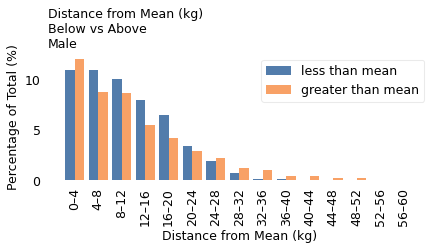

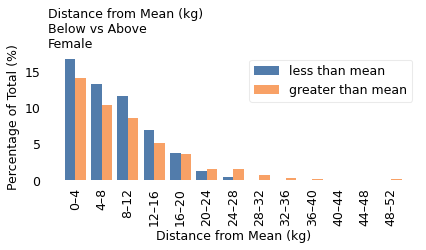

In [122]:
# Grouped bar plot:
# For each distance bin (in cm), show:
#   - % below mean
#   - % above mean
# One plot per group, no custom colors

import numpy as np
import matplotlib.pyplot as plt

def grouped_distance_from_mean_cm(data, label, bin_width_cm=4):
    data = data.dropna()

    mean = data.mean()

    below = mean - data[data < mean]
    above = data[data > mean] - mean

    max_cm = int(np.ceil(max(below.max() if len(below)>0 else 0,
                             above.max() if len(above)>0 else 0)))

    edges = np.arange(0, max_cm + bin_width_cm, bin_width_cm)

    total = len(data)

    below_counts = []
    above_counts = []
    labels = []

    for i in range(len(edges) - 1):
        lower = edges[i]
        upper = edges[i + 1]

        below_mask = (below >= lower) & (below < upper)
        above_mask = (above >= lower) & (above < upper)

        below_counts.append(below_mask.sum() / total * 100)
        above_counts.append(above_mask.sum() / total * 100)

        labels.append(f"{int(lower)}–{int(upper)}")

    x = np.arange(len(labels))
    width = 0.4

    plt.figure()
    plt.bar(x - width/2, below_counts, width,label="less than mean")
    plt.bar(x + width/2, above_counts, width,label="greater than mean")

    plt.xticks(x, labels, rotation=90)
    plt.xlabel("Distance from Mean (kg)")
    plt.ylabel("Percentage of Total (%)")
    plt.title(f"Distance from Mean (kg)\nBelow vs Above\n{label}")
    plt.tight_layout()
    plt.legend()
    plt.show()



grouped_distance_from_mean_cm(height_male, "Male")
grouped_distance_from_mean_cm(height_female, "Female")


The following function plots histograms using `plt.stairs`.

In [123]:
from utils import underride


def histplot(series, fill=True, **options):
    """Plot a histogram.

    series: Pandas Series
    fill: boolean, whether to fill below the curve
    options: passed to plt.stairs
    """
    underride(
        options,
        color="C0",
        alpha=0.7,
        lw=1.5,
    )
    bins = options.pop("bins", 40)
    counts, bins = np.histogram(series, bins=bins)
    counts = counts / counts.sum() * 100
    plt.stairs(counts, bins, **options)

    if fill:
        options.update(dict(label="", alpha=0.1))
        plt.stairs(counts, bins, fill=True, **options)

Here are the histograms of male and female heights.

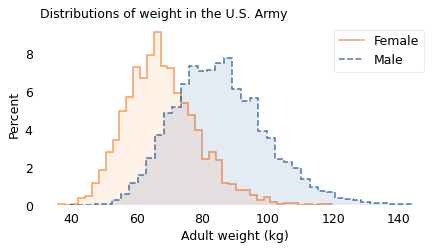

In [124]:
from utils import decorate

histplot(height_female, color="C1", label="Female")
histplot(height_male, color="C0", ls="--", label="Male")

decorate(
    xlabel="Adult weight (kg)",
    ylabel="Percent",
    title="Distributions of weight in the U.S. Army",
)

In [125]:
from scipy.stats import norm


def plot_normal_pdf(series, scale, **options):
    """Plot the PDF of a Gaussian distribution.

    series: Pandas series
    scale: multiplier used to scale the PDF
    options: passed to plt.plot
    \
    """
    mu, sigma = series.mean(), series.std()
    qs = np.linspace(series.min(), series.max())
    ps = norm.pdf(qs, mu, sigma)
    ps *= scale / np.max(ps)
    plt.plot(qs, ps, alpha=0.8, **options)

The following function plots a Gaussian curve with the same mean and std as the data.


In [126]:
from scipy.stats import norm


def plot_normal_pdf(series, scale, **options):
    """Plot the PDF of a Gaussian distribution.

    series: Pandas series
    scale: multiplier used to scale the PDF
    options: passed to plt.plot
    """
    mu, sigma = series.mean(), series.std()
    qs = np.linspace(series.min(), series.max())
    ps = norm.pdf(qs, mu, sigma)
    ps *= scale / np.max(ps)
    plt.plot(qs, ps, alpha=0.8, **options)

The scale parameter is arbitrary -- I chose it to be roughly the same height as the histogram, which is also arbitrary. Avoiding this arbitrariness is one reason I prefer to use CDFs to compare the distribution of data with a model.

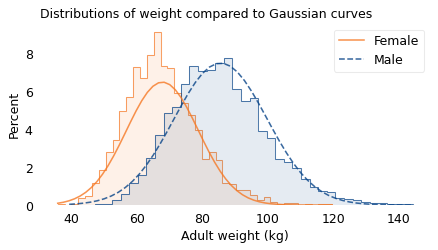

In [127]:
histplot(height_female, color="C1", lw=1)
histplot(height_male, color="C0", lw=1)
plot_normal_pdf(height_female, 6.5, color="C1", label="Female")
plot_normal_pdf(height_male, 7.5, color="C0", ls="--", label="Male")

decorate(
    xlabel="Adult weight (kg)",
    ylabel="Percent",
    title="Distributions of weight compared to Gaussian curves",
)

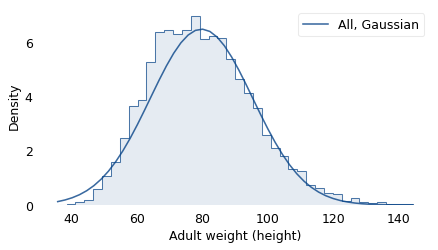

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Combine to determine shared bins
all_data = np.concatenate([height_female, height_male])
bins = np.histogram_bin_edges(all_data, bins=30)



histplot(all_data, color="C0", lw=1)

plot_normal_pdf(all_data, 6.5, color="C0",label="All, Gaussian")

decorate(
    xlabel="Adult weight (height)",
    ylabel="Density",
)

plt.legend()
plt.show()

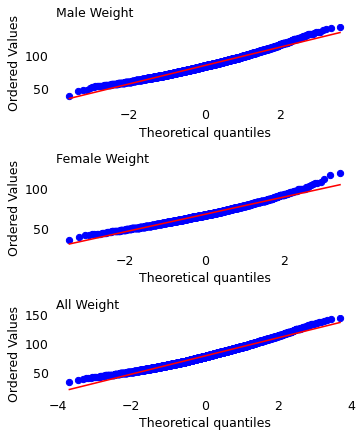

In [129]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Male
plt.figure(figsize=(5,6))
plt.subplot(3,1,1)
stats.probplot(height_male, dist="norm", plot=plt)
plt.title("Male Weight")

plt.subplot(3,1,2)
stats.probplot(height_female, dist="norm", plot=plt)
plt.title("Female Weight")
plt.tight_layout()


plt.subplot(3,1,3)
stats.probplot(all_data, dist="norm", plot=plt)
plt.title("All Weight")
plt.tight_layout()



The result shows that values generated this way can resemble the actual data.

In [ ]:
from empiricaldist import Pmf, Cdf
from utils import make_cdf

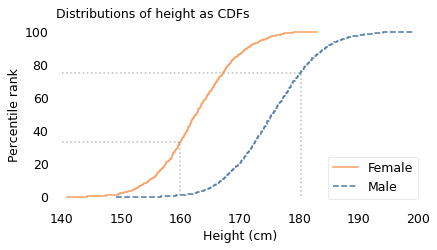

In [ ]:
def plot_lookup(series, percentile_rank, **options):
    """Plot a line representing a lookup in a CDF.

    series: Pandas Series
    percentile_rank: which percentile to look up
    options: passed to plt.plot
    """
    options = underride(options, ls=":", color="gray", alpha=0.5)
    ymax = percentile_rank
    xmin = 140
    xmax = np.percentile(series.dropna(), percentile_rank)
    plt.plot([xmin, xmax, xmax], [ymax, ymax, 0], **options)

make_cdf(height_female).step(color="C1", label="Female")
plot_lookup(height_female, 33)

make_cdf(height_male).step(ls="--", label="Male")
plot_lookup(height_male, 75)

decorate(
    xlabel="Height (cm)",
    ylabel="Percentile rank",
    xlim=[139, 201],
    title="Distributions of height as CDFs",
    loc="lower right",
)

In [132]:
measurements = [column for column in ansur_female.columns if column.lower() == column]
from empiricaldist import Pmf

def plot_pmf(series, **options):
    """Plot a PMF and a Gaussian PDF with the same mean and std.

    series: Series
    options: passed to plt.plot
    """
    pmf_series = Pmf.from_seq(series)
    mu, sigma = fit_gaussian(series)
    qs = np.linspace(-25, 25)
    ps = norm.pdf(qs, mu, sigma)
    plt.plot(qs, ps, color="gray", alpha=0.4)
    pmf_series.bar(**options)

bar_options = dict(width=1, alpha=0.4)
cdf_options = dict(xlabel=None, xlim=[-25, 25], ylabel="Percentile rank", yticks=[])
pmf_options = dict(xlabel=None, xlim=[-25, 25], ylabel="Percent", yticks=[])
measurements

['abdominalextensiondepthsitting',
 'acromialheight',
 'acromionradialelength',
 'anklecircumference',
 'axillaheight',
 'balloffootcircumference',
 'balloffootlength',
 'biacromialbreadth',
 'bicepscircumferenceflexed',
 'bicristalbreadth',
 'bideltoidbreadth',
 'bimalleolarbreadth',
 'bitragionchinarc',
 'bitragionsubmandibulararc',
 'bizygomaticbreadth',
 'buttockcircumference',
 'buttockdepth',
 'buttockheight',
 'buttockkneelength',
 'buttockpopliteallength',
 'calfcircumference',
 'cervicaleheight',
 'chestbreadth',
 'chestcircumference',
 'chestdepth',
 'chestheight',
 'crotchheight',
 'crotchlengthomphalion',
 'crotchlengthposterioromphalion',
 'earbreadth',
 'earlength',
 'earprotrusion',
 'elbowrestheight',
 'eyeheightsitting',
 'footbreadthhorizontal',
 'footlength',
 'forearmcenterofgriplength',
 'forearmcircumferenceflexed',
 'forearmforearmbreadth',
 'forearmhandlength',
 'functionalleglength',
 'handbreadth',
 'handcircumference',
 'handlength',
 'headbreadth',
 'headcir

/tmp/ipython-input-2981033837.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))


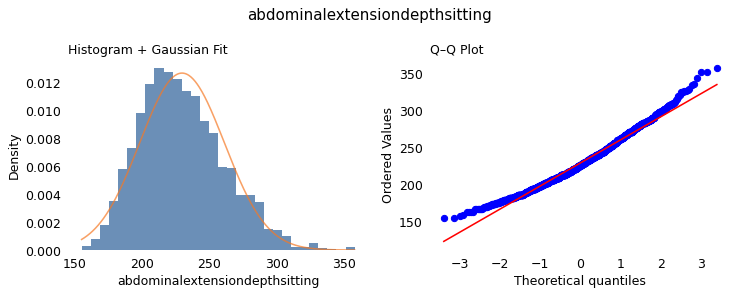

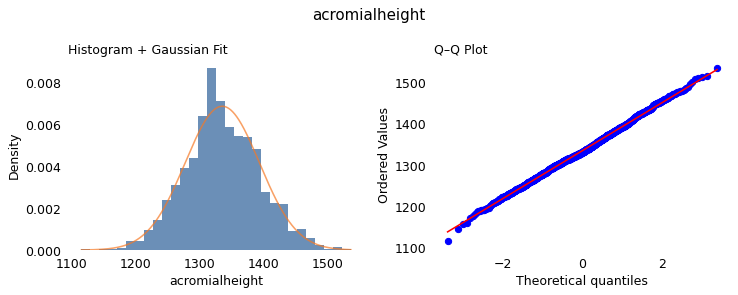

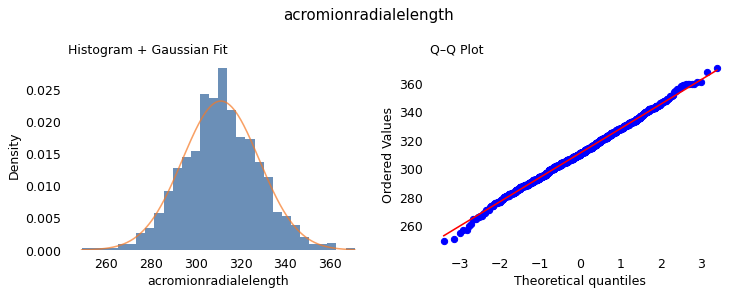

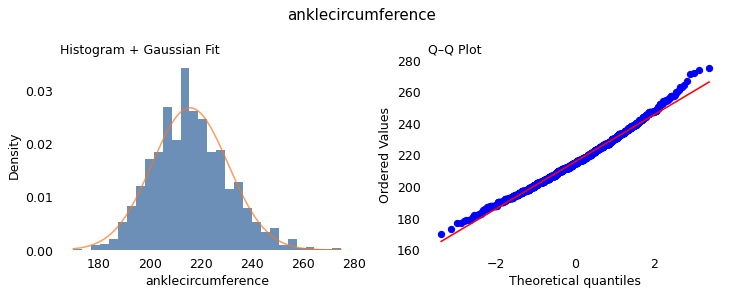

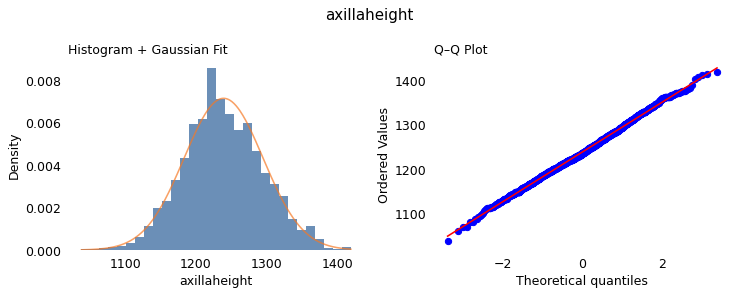

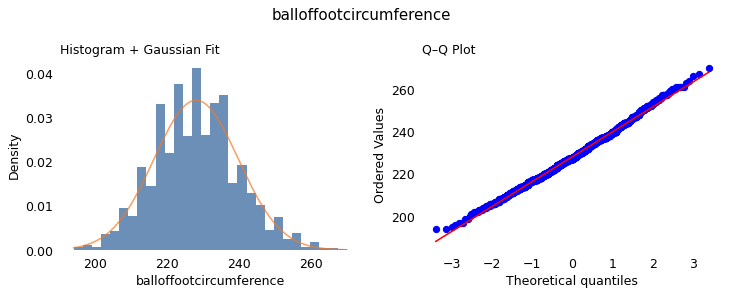

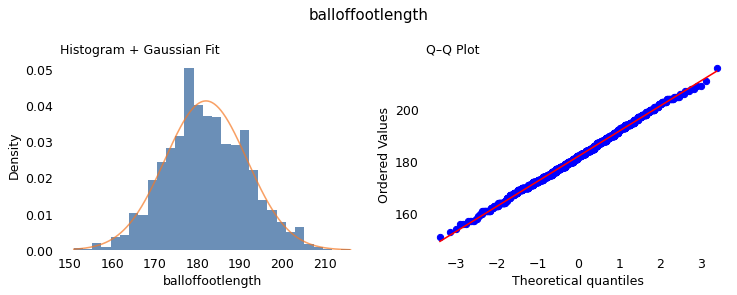

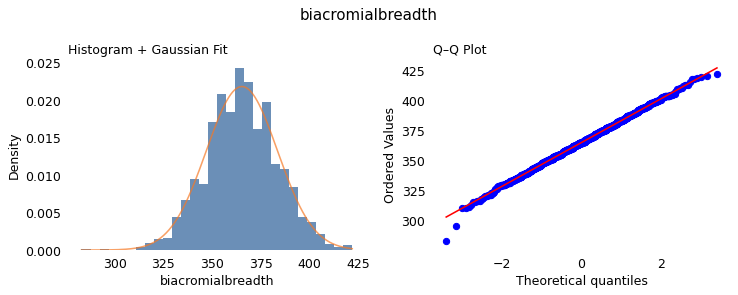

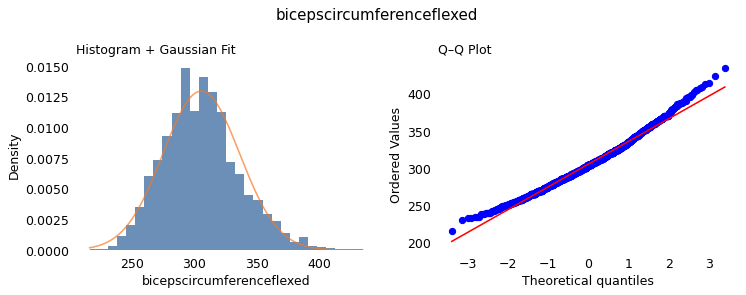

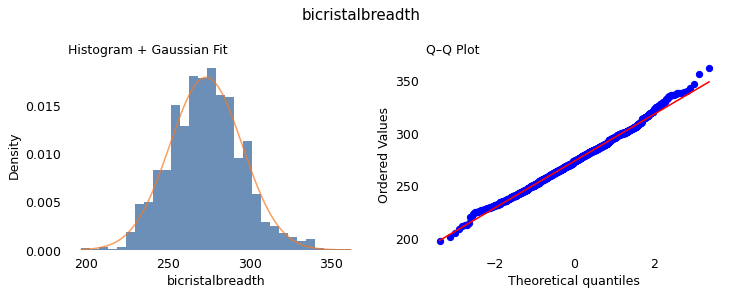

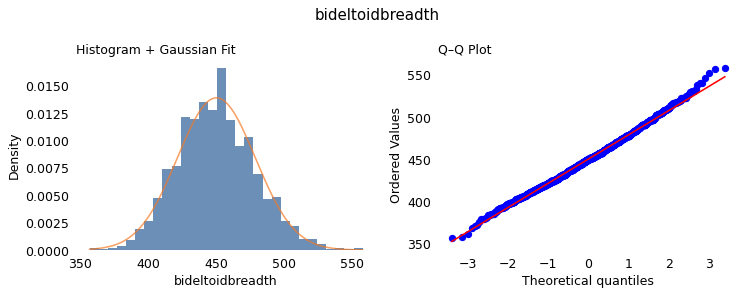

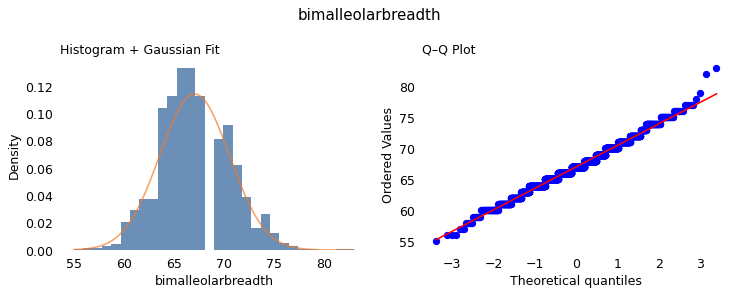

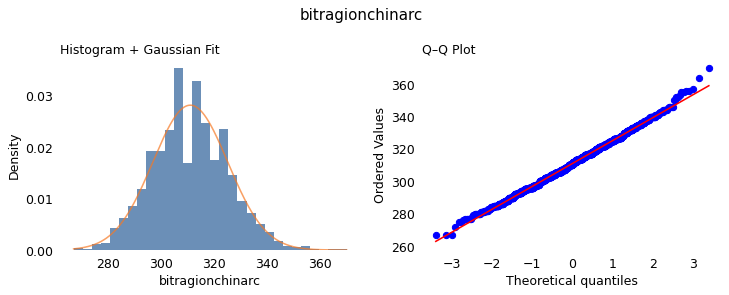

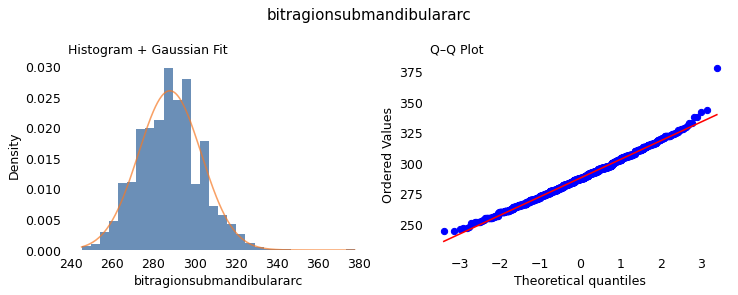

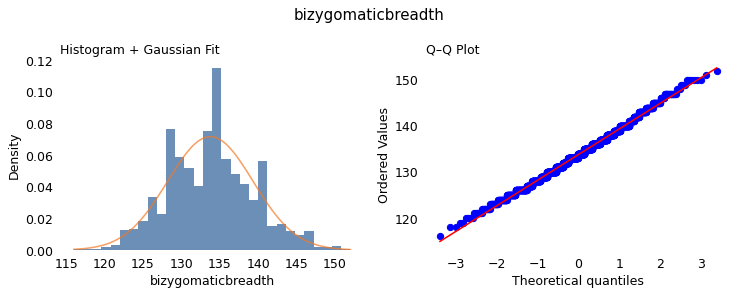

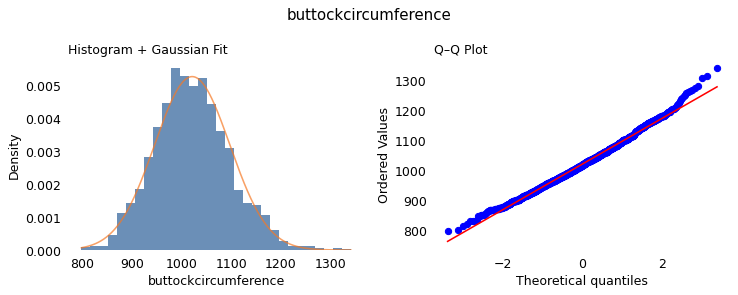

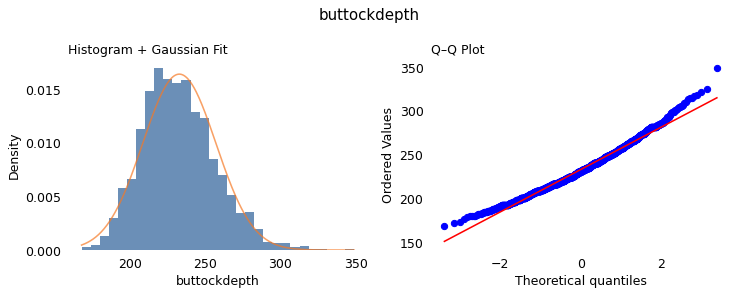

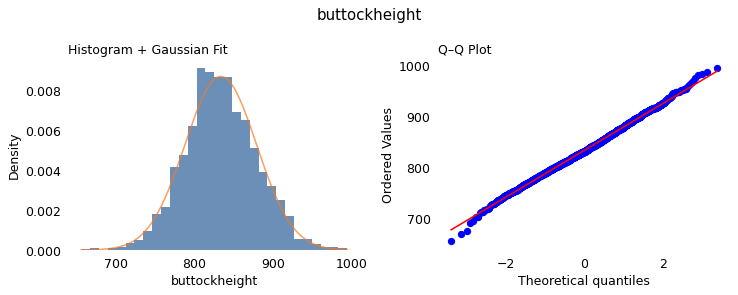

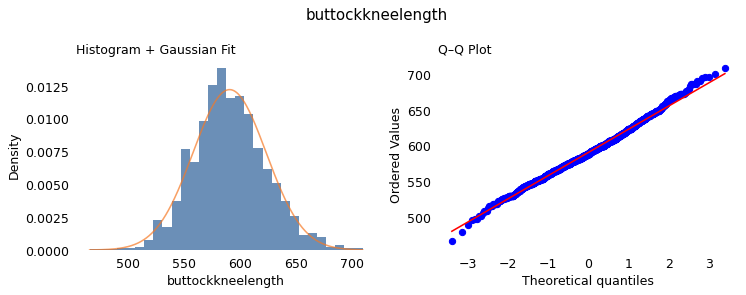

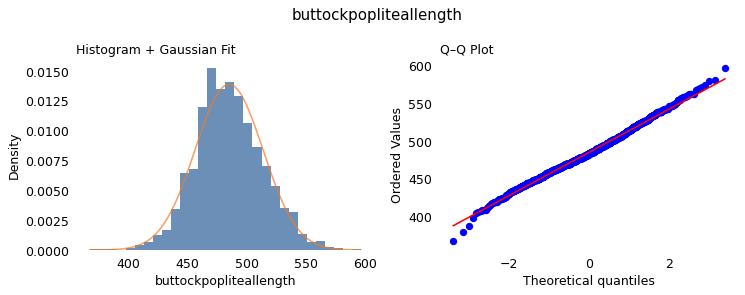

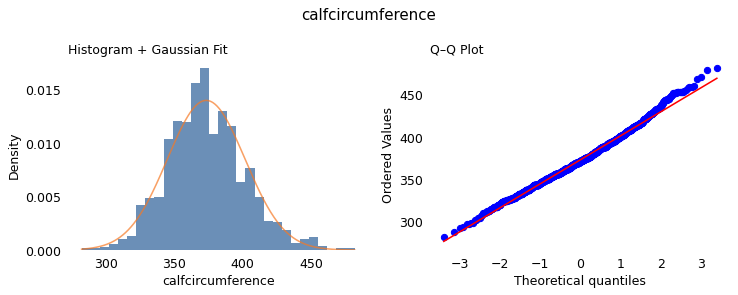

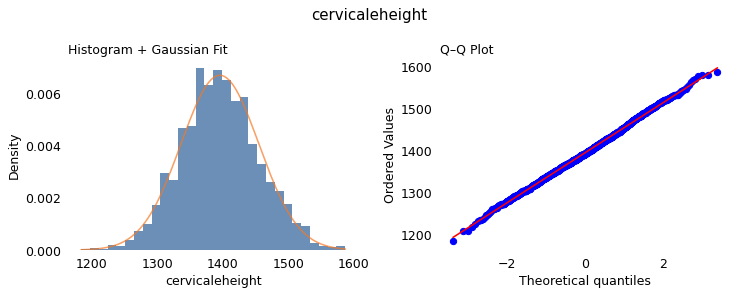

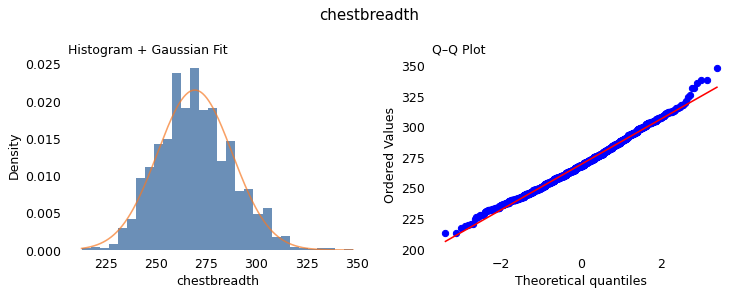

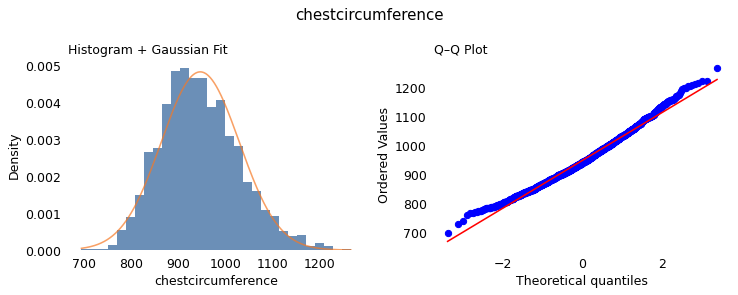

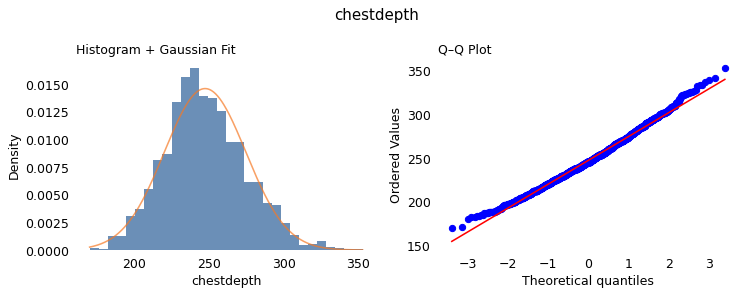

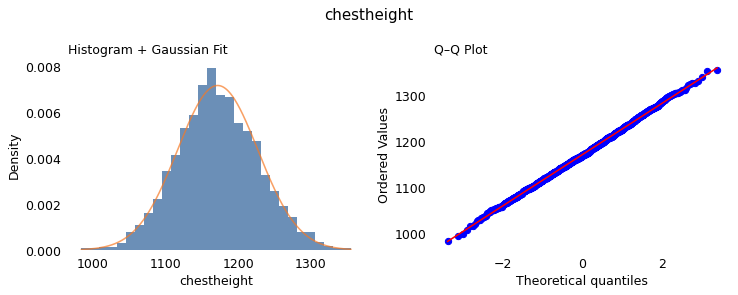

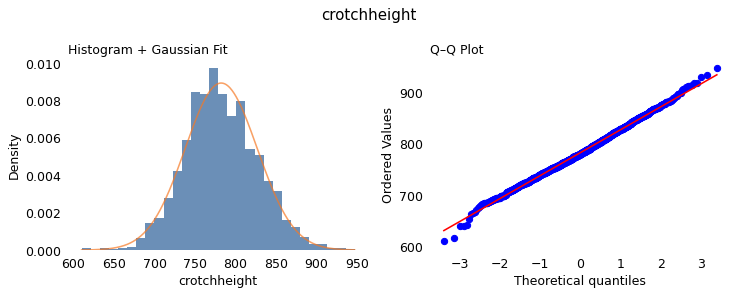

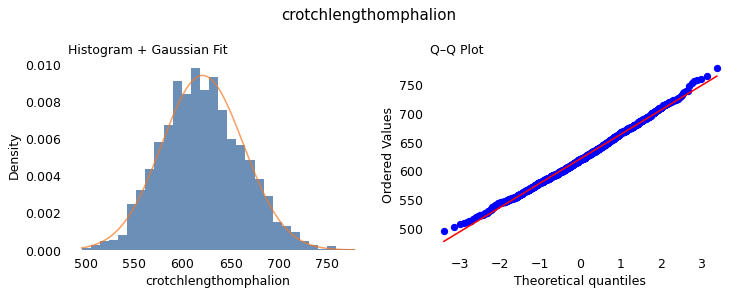

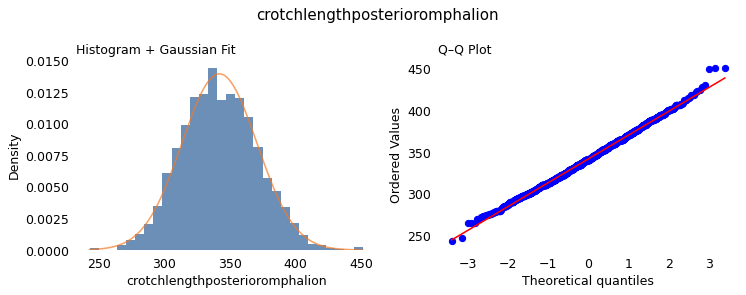

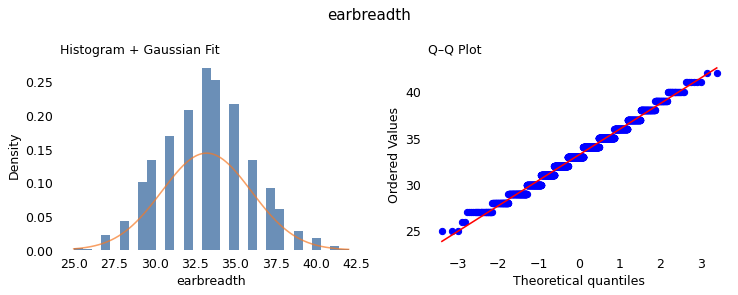

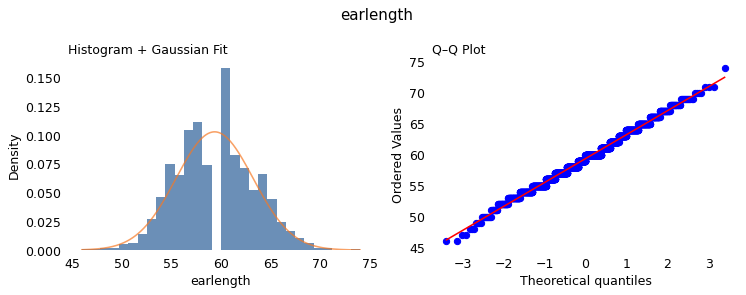

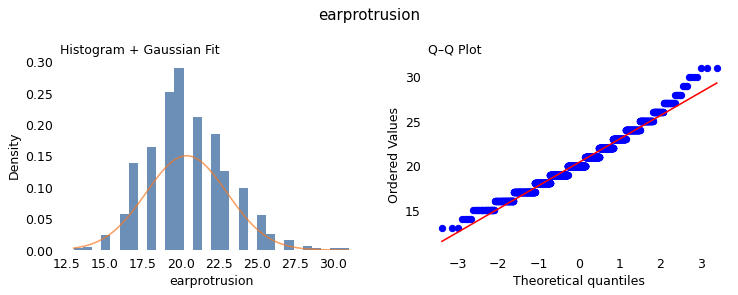

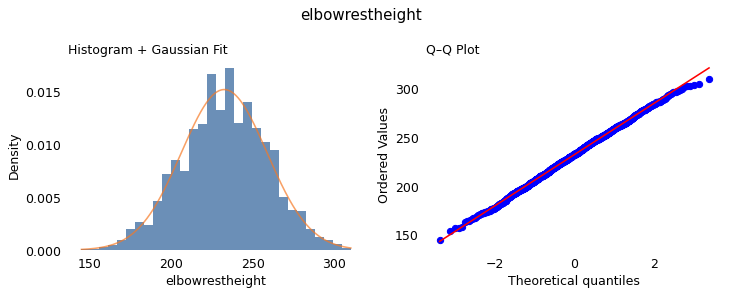

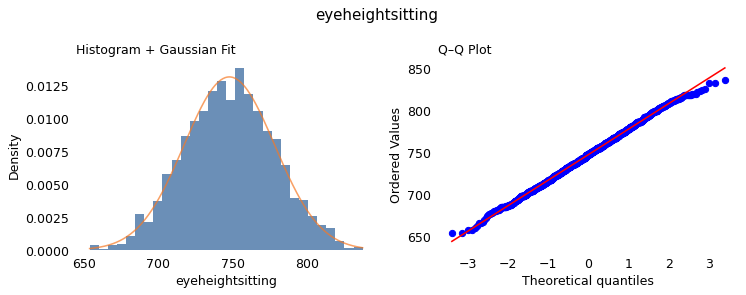

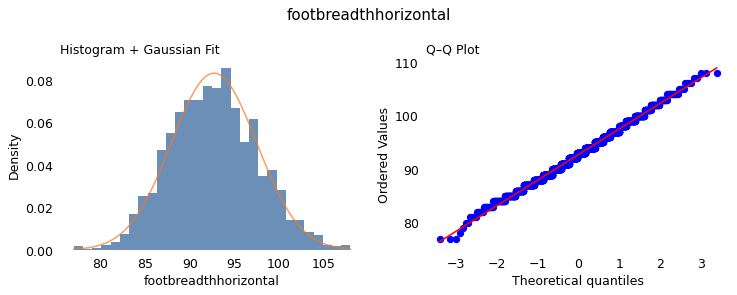

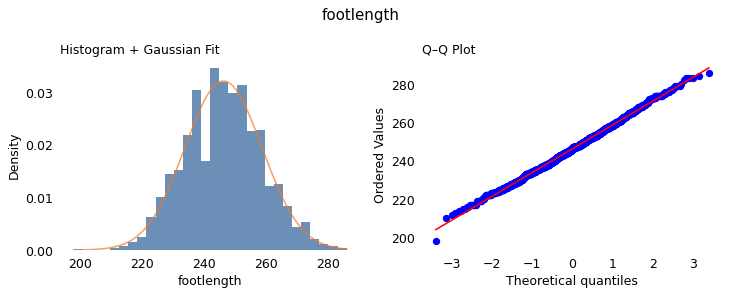

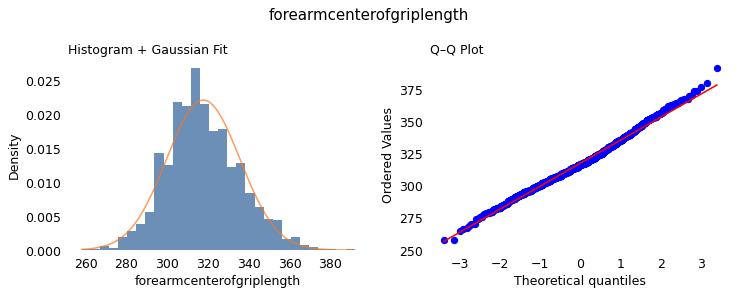

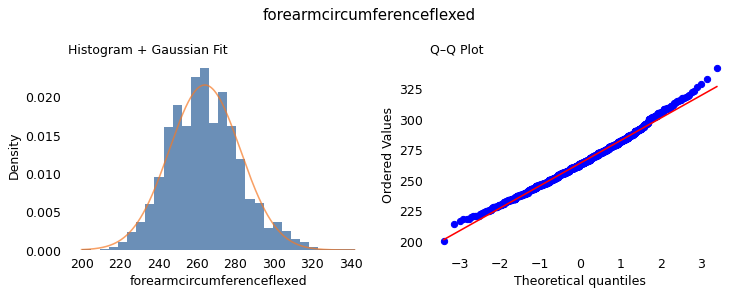

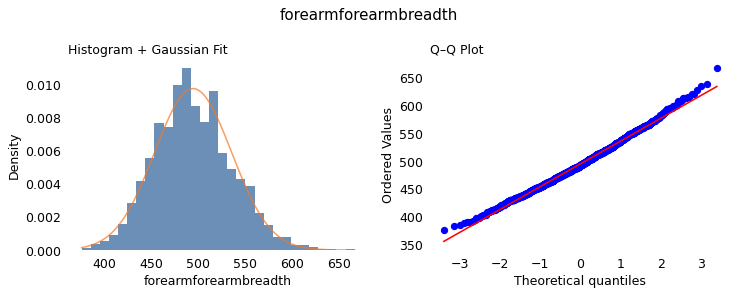

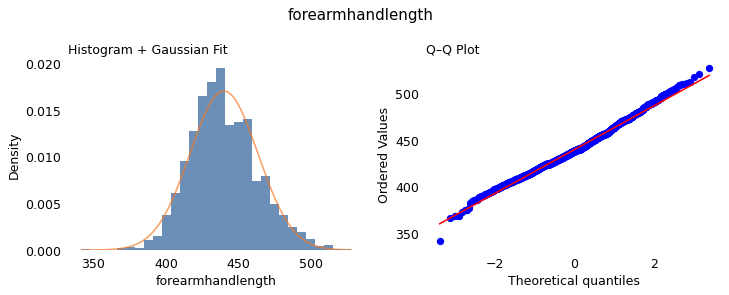

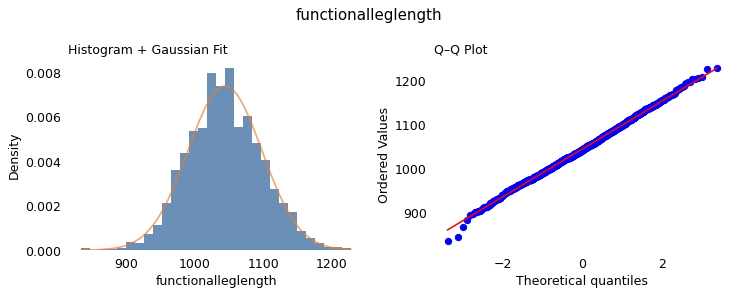

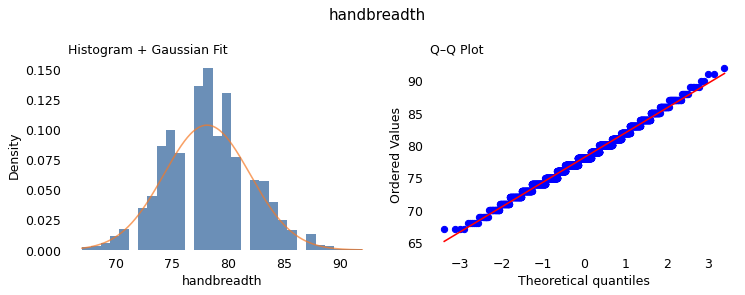

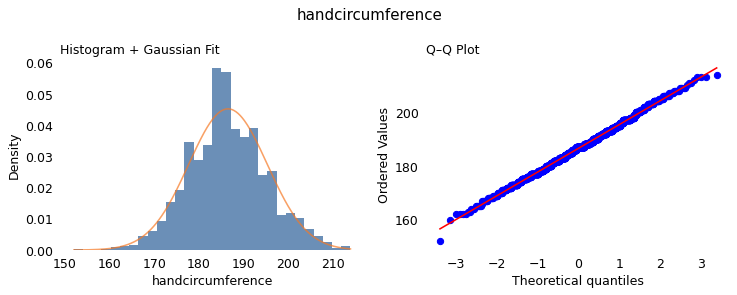

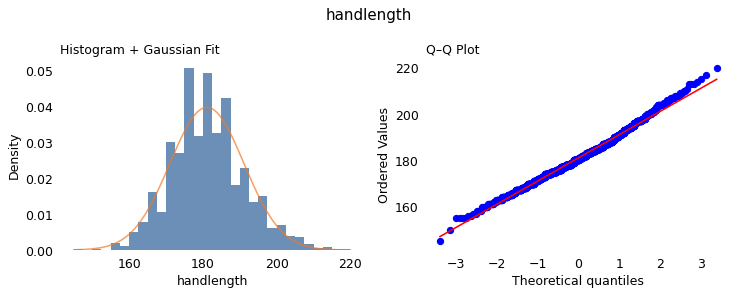

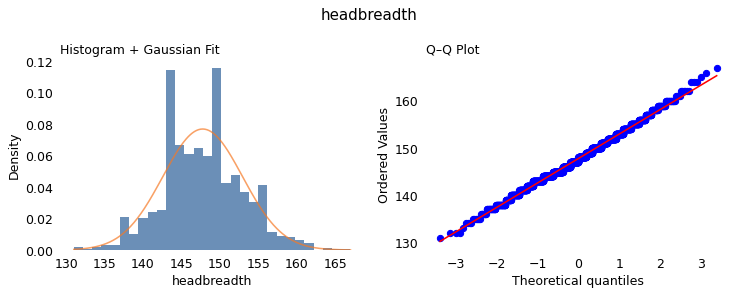

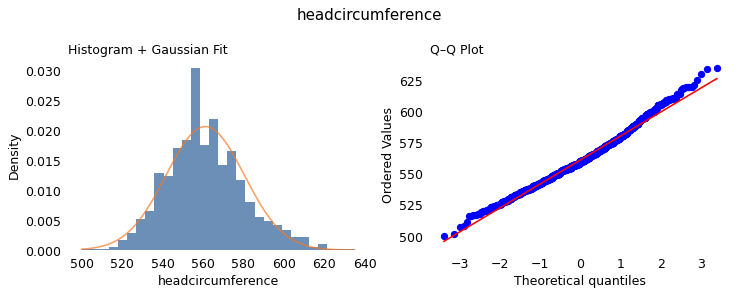

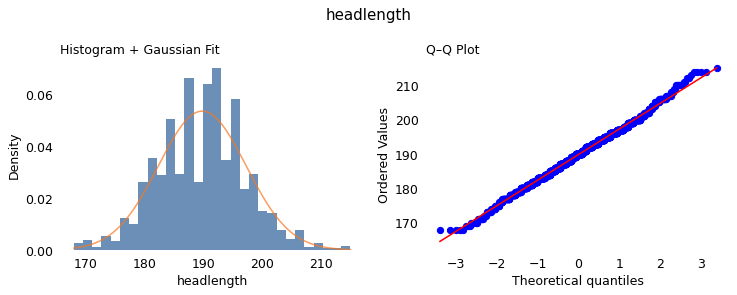

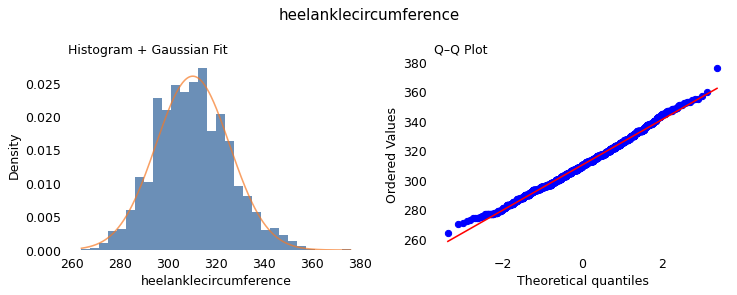

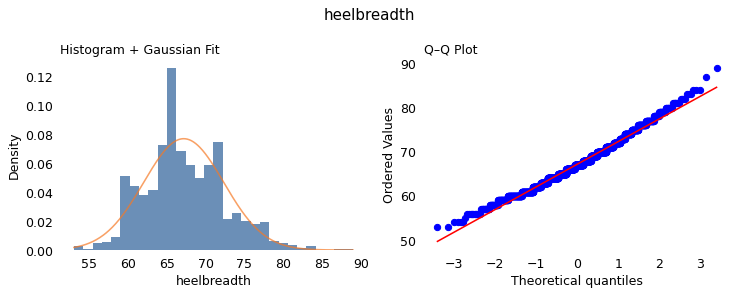

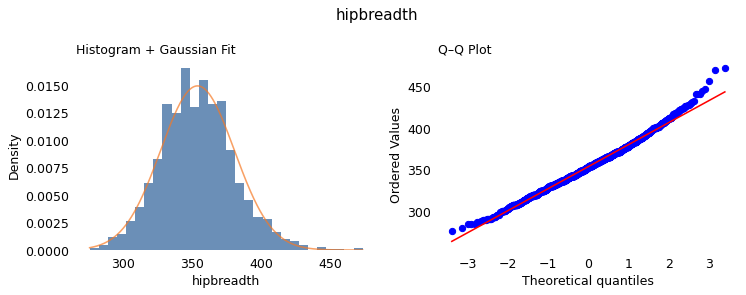

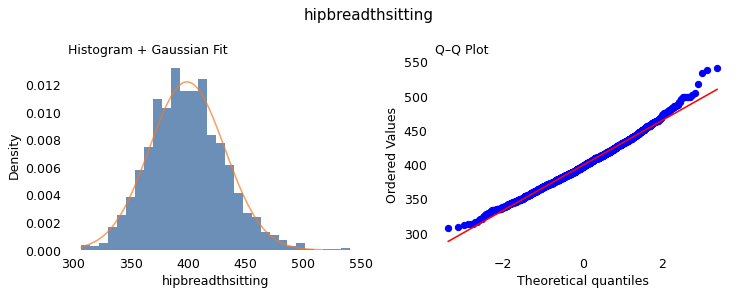

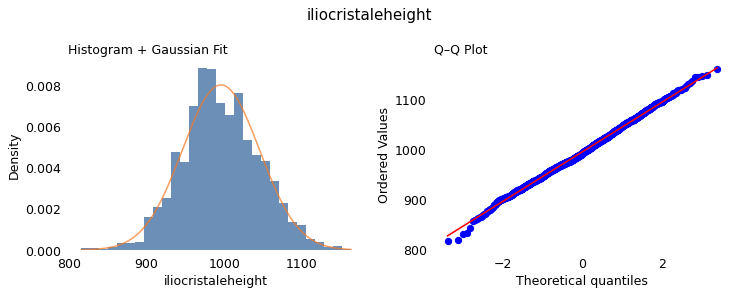

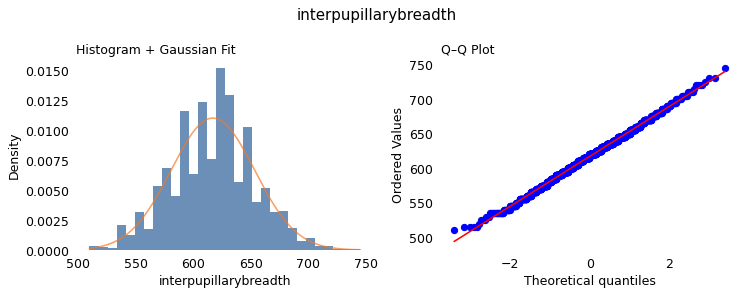

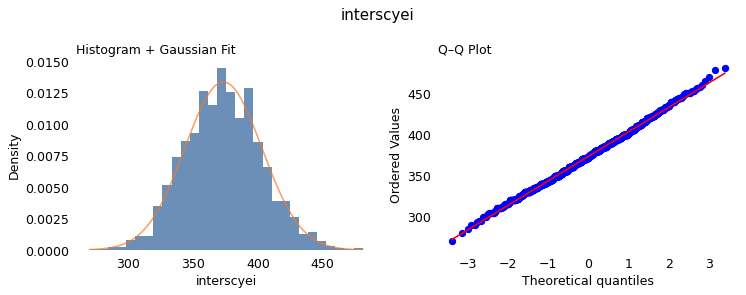

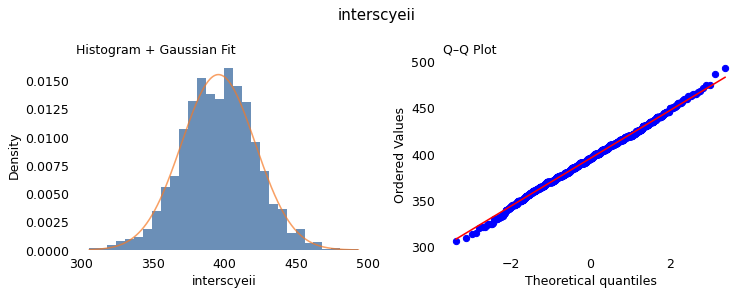

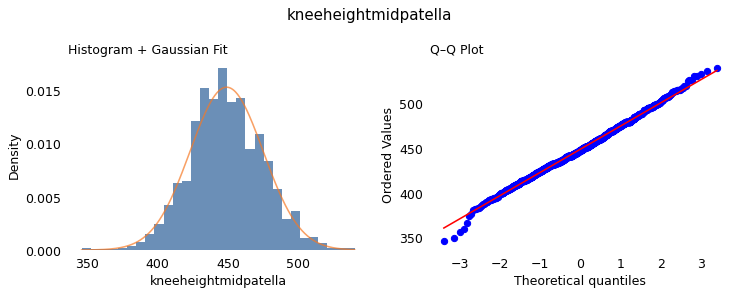

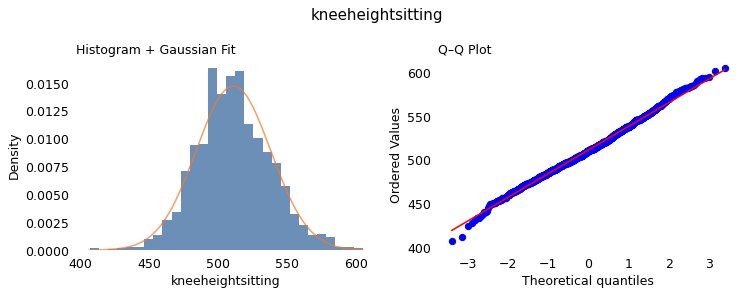

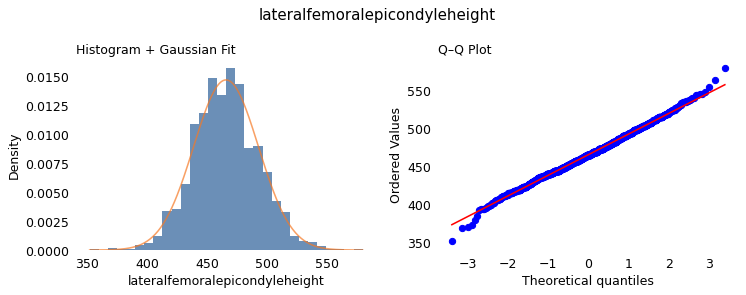

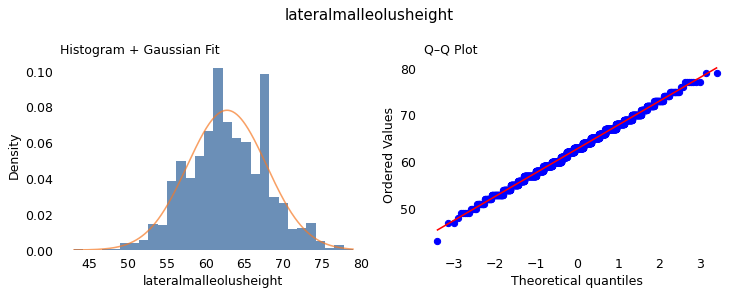

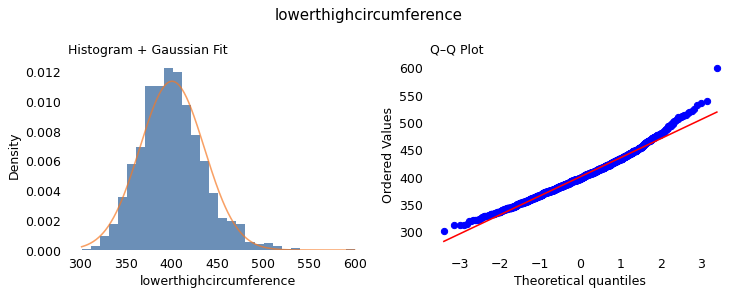

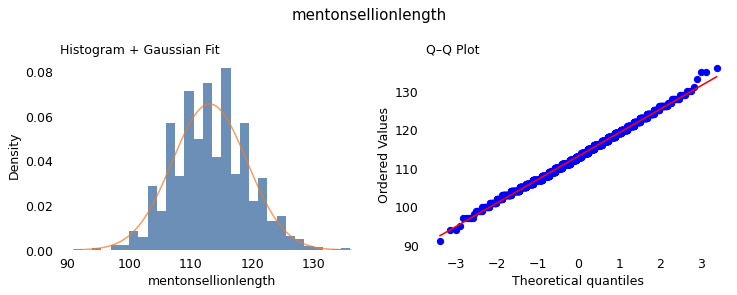

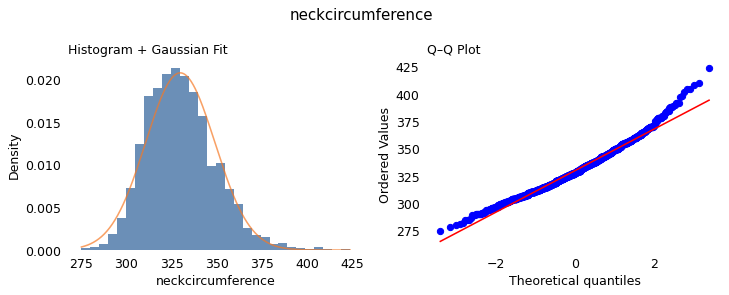

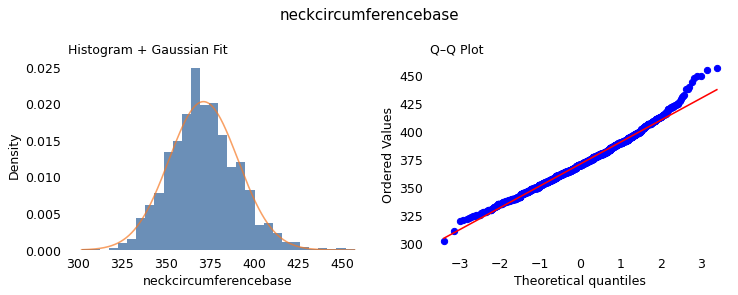

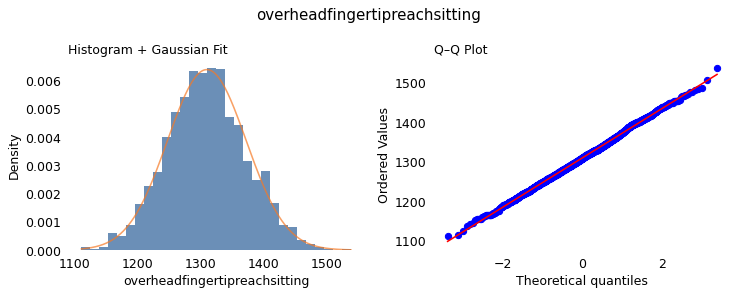

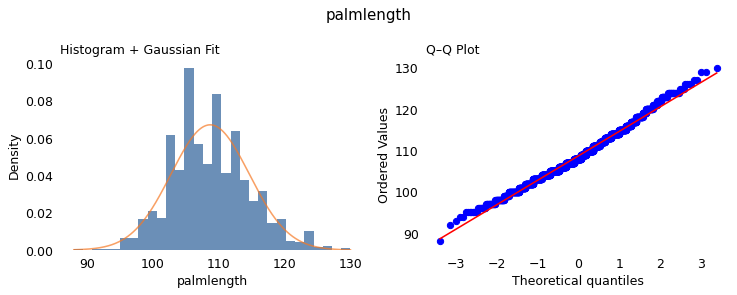

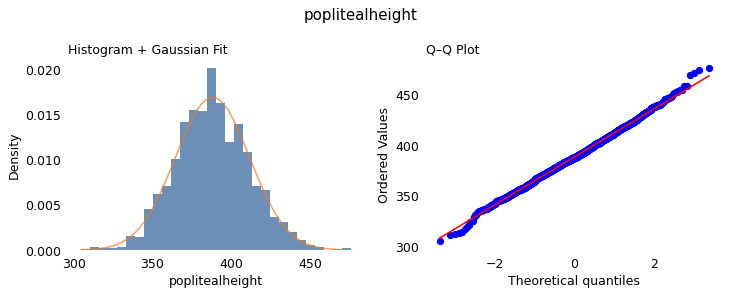

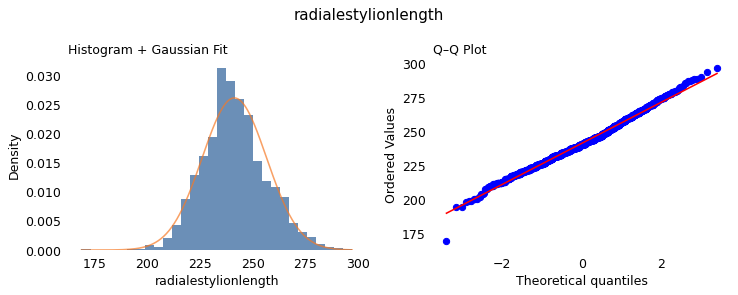

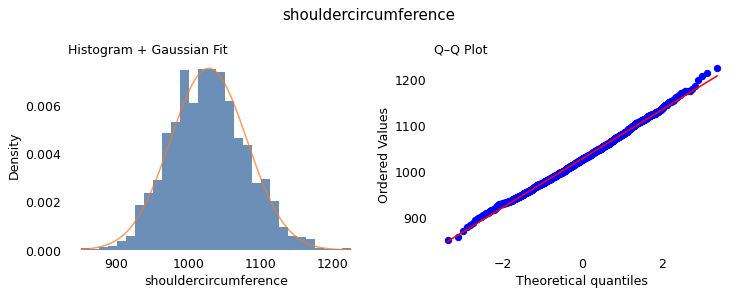

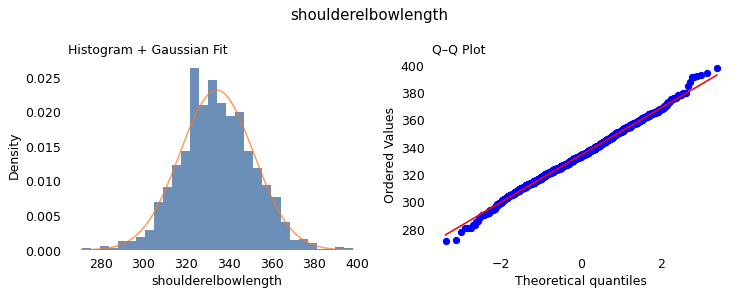

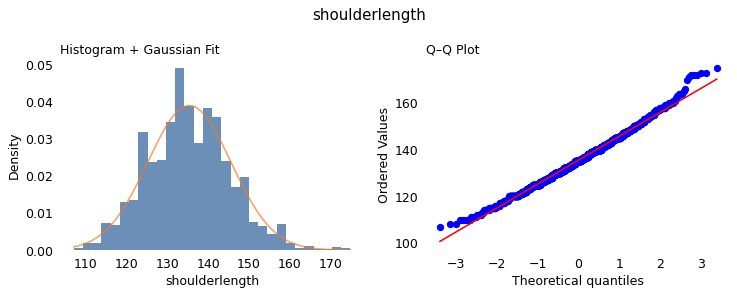

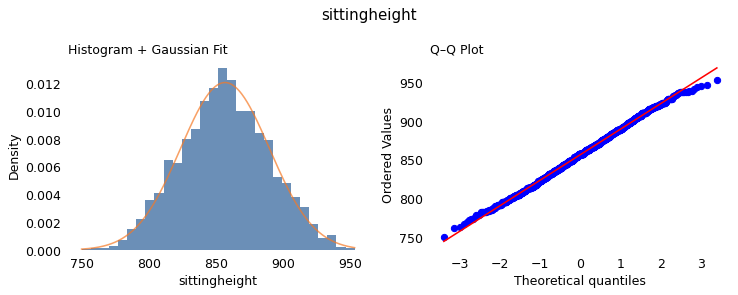

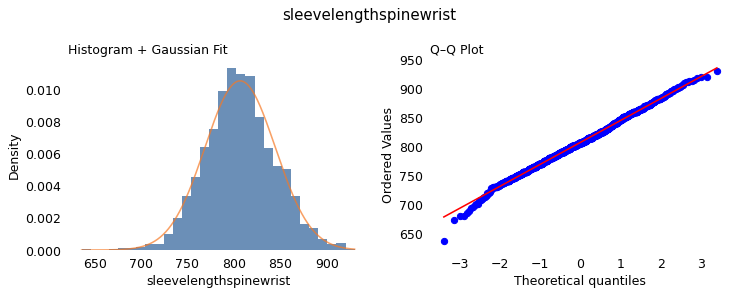

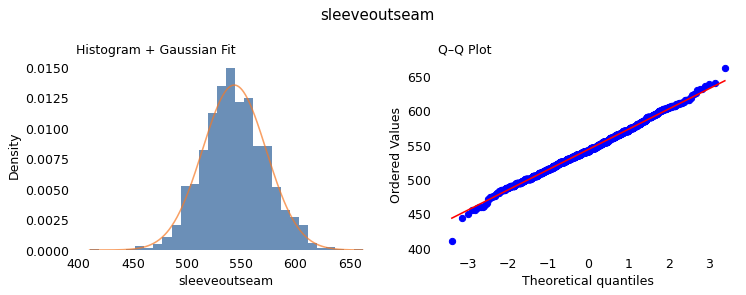

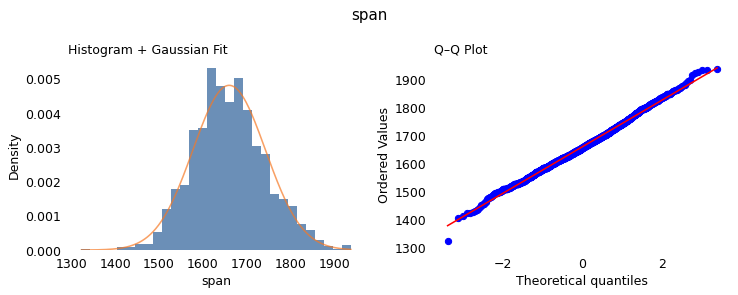

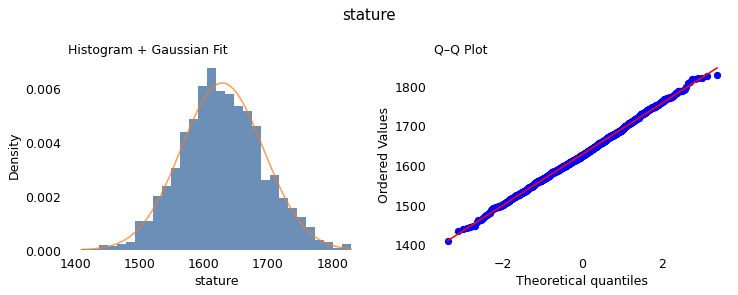

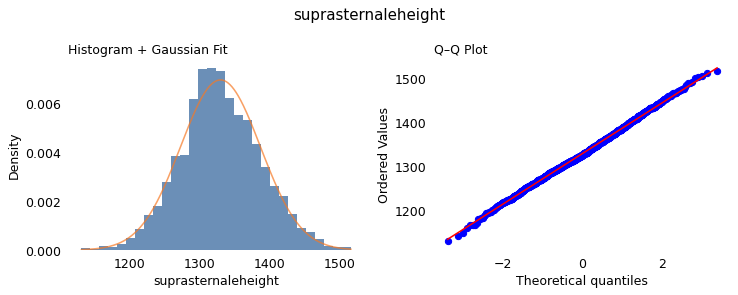

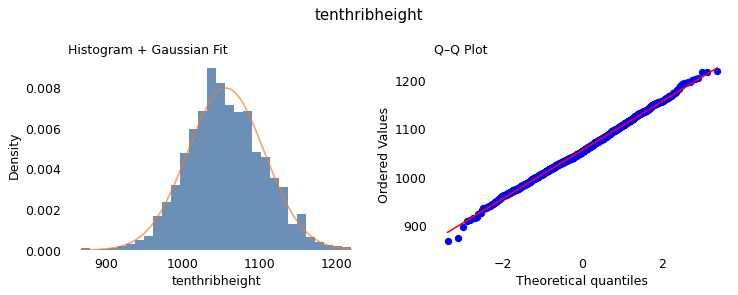

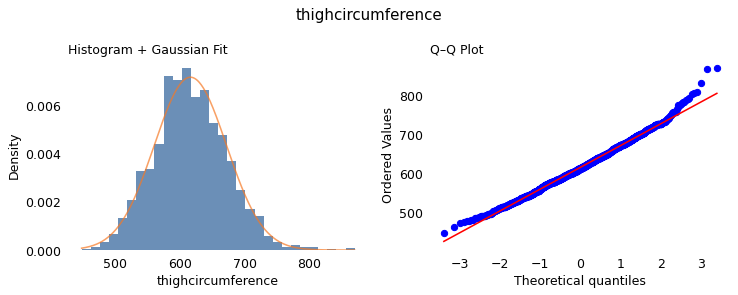

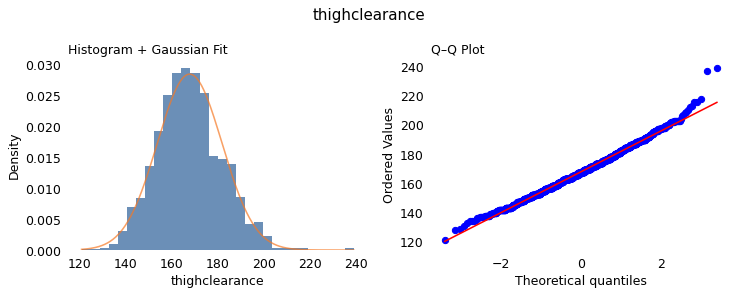

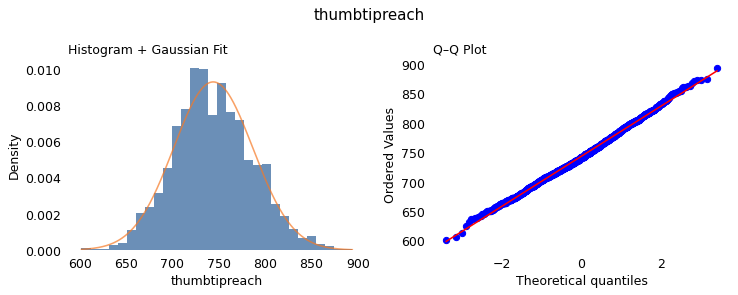

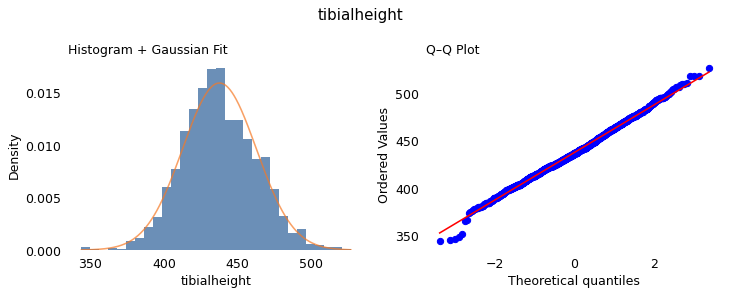

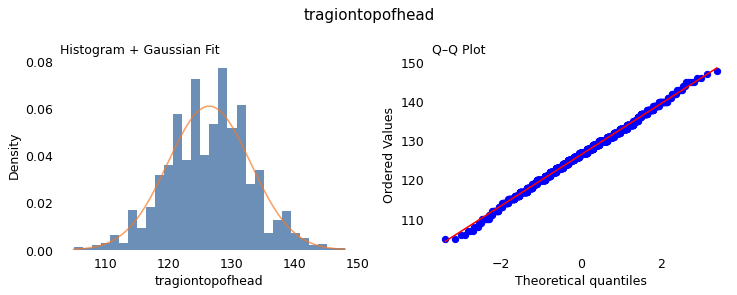

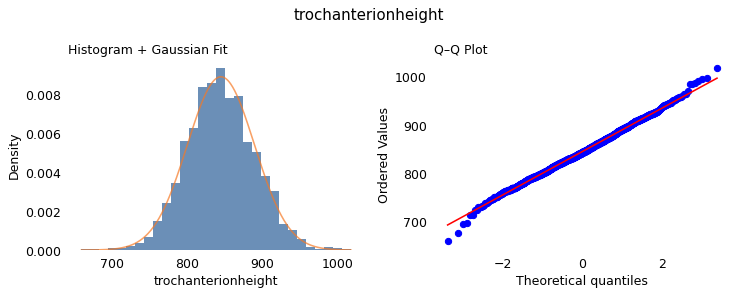

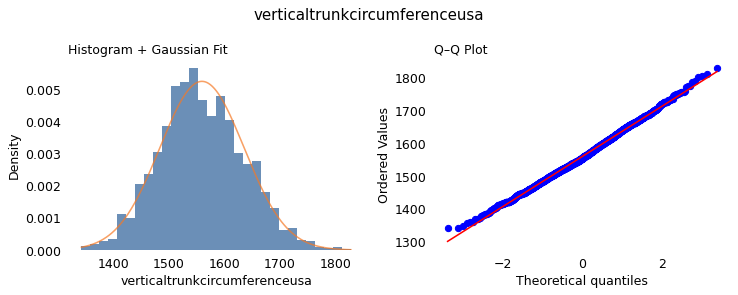

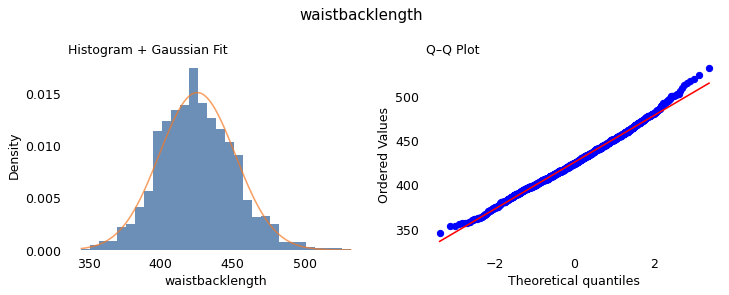

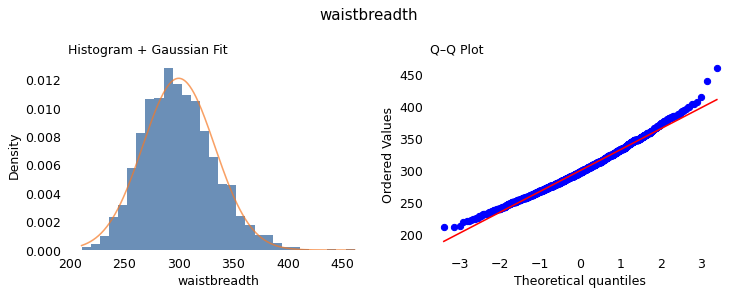

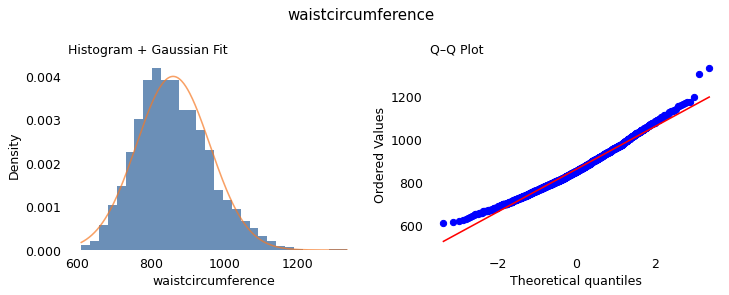

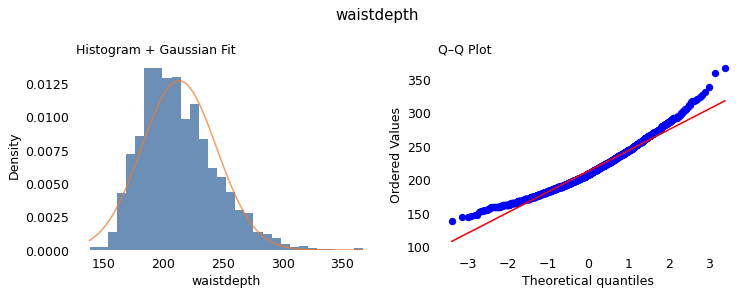

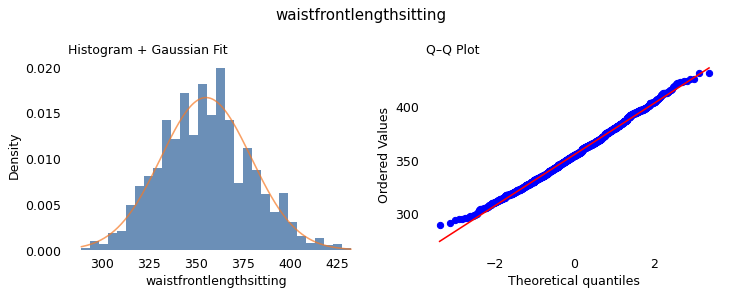

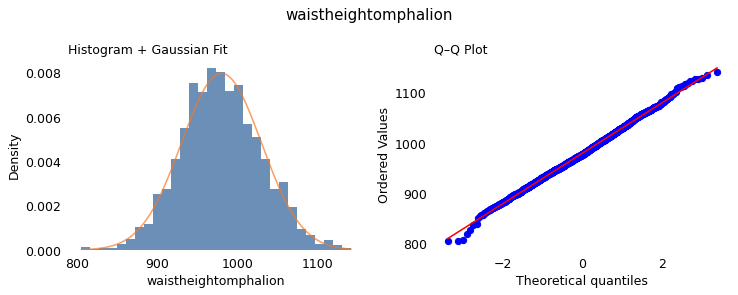

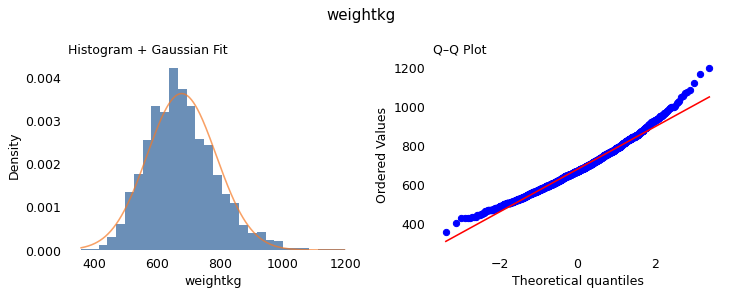

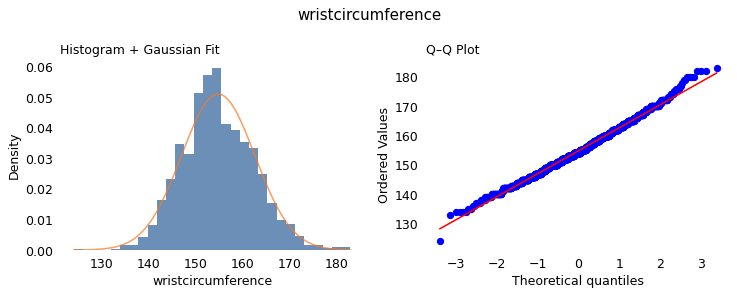

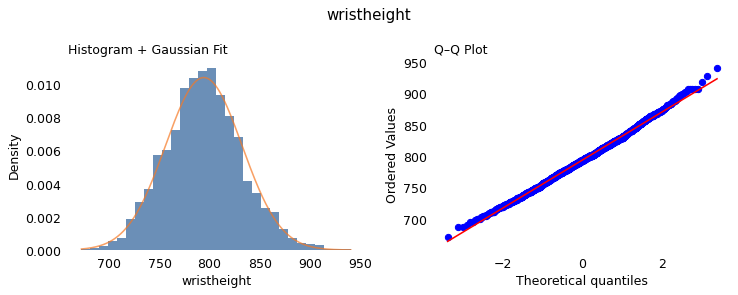

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot

df = ansur_female  # or ansur_male

def fit_gaussian(series):
    mu = np.mean(series)
    sigma = np.std(series, ddof=0)  # MLE std
    return mu, sigma

for trait in measurements:
    series = df[trait].dropna().values

    if len(series) < 10:
        continue  # skip degenerate cases

    mu, sigma = fit_gaussian(series)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # -------------------------------------------------
    # Left: Histogram + Gaussian fit
    # -------------------------------------------------
    axes[0].hist(series, bins=30, density=True, alpha=0.6)

    x = np.linspace(series.min(), series.max(), 400)
    axes[0].plot(x, norm.pdf(x, mu, sigma))

    axes[0].set_title("Histogram + Gaussian Fit")
    axes[0].set_xlabel(trait)
    axes[0].set_ylabel("Density")

    # -------------------------------------------------
    # Right: Q-Q Plot
    # -------------------------------------------------
    probplot(series, dist="norm", plot=axes[1])
    axes[1].set_title("Q–Q Plot")

    fig.suptitle(trait)
    plt.tight_layout()
    plt.savefig(trait + "gaussfit.png")

In [ ]:
len(measurements)

93

To find the measurements that fit a Gaussian model the best and the worst, I use the following function, which computes the maximum vertical distance between the CDF of the data and the model.

In [ ]:
from utils import fit_gaussian


def ks_distance(series):
    """Compute the Kolmogorov-Smirnov distance.

    returns: the maximum vertical distance between data and model,
    and the quantile where it happens
    """
    mu, sigma = fit_gaussian(series)
    cdf = Cdf.from_seq(series)
    norm_cdf = norm.cdf(cdf.qs, mu, sigma)
    diff = np.abs(cdf - norm_cdf)
    idx_diff = diff.idxmax()
    return diff.max(), idx_diff

The following function computes this distance for all of the measurements.

In [ ]:
def all_ks_distances(df, tag, measurements):
    """Compute K-S distances for all measurements.

    df: DataFrame
    tag: string added to the list of results
    measurements: list of column names in df

    returns: list of (distance, location, tag, varname) tuples
    """
    res = []

    for varname in measurements:
        series = df[varname]
        diff, idx_diff = ks_distance(series)
        res.append((diff, idx_diff, tag, varname))

    return res

Now we can make a list of results for all measurements, male and female.

In [ ]:
res_female = all_ks_distances(ansur_female, "female", measurements)

In [ ]:
res_male = all_ks_distances(ansur_male, "male", measurements)

In [ ]:
res = res_female + res_male
res.sort()

In [ ]:
ks = np.array([k for k, _, _, _ in res])

In [ ]:
np.percentile(ks, [25, 50, 75])

array([0.01326444, 0.01713559, 0.02188356])

Here are the measurements where the distance between the data and the model is smallest.

And here are the measurements where it's the biggest.

In [ ]:
series = ansur_male["poplitealheight"] / 10
diff, idx_diff = ks_distance(series)
diff * 100, idx_diff

(0.7976621308029785, 41.7)

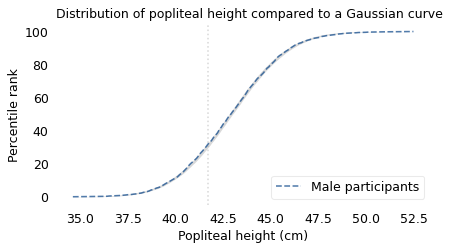

In [ ]:
plt.axvline(idx_diff, color="gray", ls=":", alpha=0.3)
gaussian_plot(series, label="Male participants", style="--")
decorate(
    xlabel="Popliteal height (cm)",
    ylabel="Percentile rank",
    title="Distribution of popliteal height compared to a Gaussian curve",
    loc="lower right",
)

The measurement that is the worst match to the Gaussian model is the forearm length of the female participants, which is the distance I mentioned earlier between the  radiale landmark on the right elbow and the stylion landmark on the right wrist.

The following figure shows the distribution of these measurements and a Gaussian model.
The maximum vertical distance between them is 4.2 percentile ranks, at the location indicated by the vertical dotted line; it looks like there are more measurements between 24 and 25 cm than we would expect in a Gaussian distribution.

In [ ]:
# "distance between the radiale landmark on the right elbow and
# the stylion landmark on the right wrist"
# basically, forearm length

series = ansur_female["interpupillarybreadth"] / 10
diff, idx_diff = ks_distance(series)
diff * 100, idx_diff

(5.6542891239820205, 61.4)

In [ ]:
# "distance between the radiale landmark on the right elbow and
# the stylion landmark on the right wrist"
# basically, forearm length

series = ansur_female["interpupillarybreadth"] / 10
diff, idx_diff = ks_distance(series)
diff * 100, idx_diff

(5.6542891239820205, 61.4)

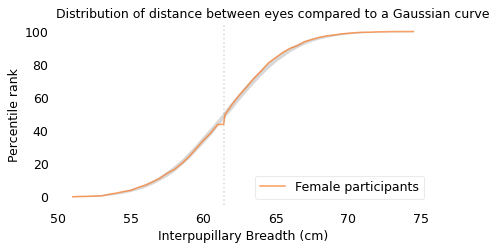

In [ ]:
plt.axvline(idx_diff, ls=":", color="gray", alpha=0.3)
gaussian_plot(
    ansur_female["interpupillarybreadth"] / 10, label="Female participants", color="C1"
)
decorate(
    xlabel="Interpupillary Breadth (cm)",
    ylabel="Percentile rank",
    title="Distribution of distance between eyes compared to a Gaussian curve",
    loc="lower right",
)

Out of almost 200 measurements, this is the one that is the *least* well modeled by the Gaussian distribution; even so, the deviation is small, and for many purposes, the Gaussian model would be good enough.

What I reported in the book is `radialestylionlength`, which is second on the list and seems to be legitimately the measurement that is the worst fit for the model.

In [ ]:
# "distance between the radiale landmark on the right elbow and
# the stylion landmark on the right wrist"
# basically, forearm length

series = ansur_female["radialestylionlength"] / 10
diff, idx_diff = ks_distance(series)
diff * 100, idx_diff

(4.154583865194262, 24.6)

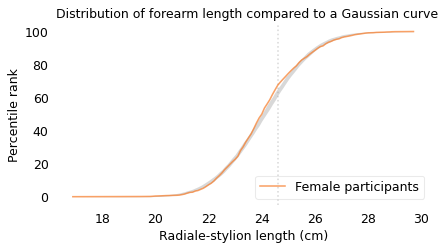

In [ ]:
plt.axvline(idx_diff, ls=":", color="gray", alpha=0.3)
gaussian_plot(
    ansur_female["radialestylionlength"] / 10, label="Female participants", color="C1"
)
decorate(
    xlabel="Radiale-stylion length (cm)",
    ylabel="Percentile rank",
    title="Distribution of forearm length compared to a Gaussian curve",
    loc="lower right",
)

## The Myth of the "Average Man"

We've seen that variation in physical characteristics is often well modeled by a Gaussian distribution.
A characteristic of these distributions is that most people are close to the mean, with fewer and fewer people far from the mean in either direction.
But as I said in the introduction of this chapter: what is true when we consider a single characteristic turns out to be counter-intuitively false when we consider a few characteristics at once, and spectacularly false when we consider more than a few.
In particular, when we consider the many ways each individual differs from the average, we find that people close to average in every way are rare or non-existent.

This observation was made most famously by Gilbert Daniels in a Technical Report he wrote for the U.S. Air Force in 1952, with the title "The 'Average Man?'".
In the introduction he explains:

> The tendency to think in terms of the "average man" is a pitfall into which many persons blunder when attempting to apply human body size data to design problems. Actually, it is virtually impossible to find an "average man" in the Air Force population.

As evidence, he used data from the Air Force Anthropometric Survey of 1950, a precursor of the ANSUR dataset we've used in this chapter.
This dataset includes 131 measurements from 4063 Air Force "flying personnel", all male.
From these, Daniels selected 10 measurements "useful in clothing design".
Coyly, he mentions that we would get similar results if we chose measurements useful in airplane cockpit design, which was the actual but unstated purpose of the report.

Daniels finds that of the 4063 men, 1055 were of "approximately average" height, which he defines to be within the "middle 30\% of the total population".
Of those, 302 were of approximately average chest circumference.
Of those, 143 were of approximately average sleeve length.

He continues, filtering out anyone who falls outside the middle 30\% of the population by any of the other measurements.
In the end, he finds 3 who make it past the first eight measurements, 2 who make it past the first nine, and 0 who were approximately average on all ten.
If a uniform -- or cockpit -- was designed to fit the average man on all 10 measurements, it would fit no one.

Daniels suggests that "conclusions similar to those reported here would have been reached if the same type of analysis had been applied to body size data based on almost any group of people".
To see if he's right, we'll replicate his analysis using data from the participants in the ANSUR survey.

Many of the measurements in the ANSUR survey are the same as in the Air Force survey, but not all.
Of the ten Daniels chose, I found eight identical measurements in the ANSUR dataset and two replacements that are similar.

Here are the measurements from ANSUR that are the closest to the measurements in Daniels's report.

In [ ]:
daniels_measurements = [
    "stature",
    "chestcircumference",
    "sleevelengthspinewrist",
    "crotchheight",
    "verticaltrunkcircumferenceusa",
    "hipbreadthsitting",
    "neckcircumference",
    "waistcircumference",
    "thighcircumference",
    "crotchlengthposterioromphalion",
]

In [ ]:
np.any(ansur_male.describe().loc["count"] != 4082)

False

In [ ]:
res = []

for varname in daniels_measurements:
    series = ansur_male[varname] / 10
    mu, sigma = series.mean(), series.std()
    num_std = 0.3
    low, high = np.array([-num_std, num_std]) * sigma + mu
    # low, high = np.percentile(series, [35, 65])
    nearly_average = series.between(low, high)
    frac = nearly_average.mean() * 100
    res.append((varname, mu, sigma, low, high, frac))

The following table shows the names of these measurements, the mean and standard deviations of the values, the low and high ends of the range considered "approximately average", and the percentage of survey participants who fall in the range.

You might notice that these percentages are lower than the 30\% Daniels claims.
In an appendix, he explains that he used "a range of plus or minus three-tenths of a standard deviation" from the mean.
He chose this range because it seemed "reasonable" to him and because it is the "equivalent of a full clothing size".
To reproduce his analysis, I followed the specification in the appendix.

In [ ]:
columns = ["Measurement", "Mean", "Std Dev", "Low", "High", "% in range"]
index = [
    "Stature (height)",
    "Chest Circumference",
    "Sleeve Length",
    "Crotch Height",
    "Vertical Trunk Circ.",
    "Hip Breadth Sitting",
    "Neck Circumference",
    "Waist Circumference",
    "Thigh Circumference",
    "Crotch Length",
]
table = pd.DataFrame(res, columns=columns, index=index)
table.index.name = "Measurement"

In [ ]:
table["Std Dev"].values.round(1)

array([ 6.9,  8.7,  4. ,  4.6,  9. ,  3. ,  2.6, 11.2,  5.8,  2.9])

In [ ]:
from utils import compress_table

compress_table(table.drop(columns=["Measurement"]).round(1))

Measurement,Mean,Std Dev,Low,High,% in range
Stature (height),175.6,6.9,173.6,177.7,23.2
Chest Circumference,105.9,8.7,103.2,108.5,22.9
Sleeve Length,89.6,4.0,88.4,90.8,23.1
Crotch Height,84.6,4.6,83.2,86.0,22.1
Vertical Trunk Circ.,166.5,9.0,163.8,169.2,24.2
Hip Breadth Sitting,37.9,3.0,37.0,38.8,24.8
Neck Circumference,39.8,2.6,39.0,40.5,25.2
Waist Circumference,94.1,11.2,90.7,97.4,22.1
Thigh Circumference,62.5,5.8,60.8,64.3,24.9
Crotch Length,35.6,2.9,34.7,36.5,22.1


In [ ]:
table["% in range"].mean()

23.466438020578146

Here are the measurements where there are the biggest differences between the Daniels dataset and the ANSUR dataset (you can ignore the two very large differences, which are the result of using measurements that are defined differently).

The other differences suggest that members of the Army and Marines now are bigger than members of the Air Force in 1950.

In [ ]:
mean_daniels = [175.5, 98.6, 85.5, 83.4, 164.6, 106.0, 38.0, 81.4, 56.9, 71.6]

In [ ]:
(table["Mean"] - mean_daniels) / mean_daniels * 100

Stature (height)         0.069208
Chest Circumference      7.373787
Sleeve Length            4.777443
Crotch Height            1.430448
Vertical Trunk Circ.     1.142422
Hip Breadth Sitting    -64.217226
Neck Circumference       4.644460
Waist Circumference     15.550051
Thigh Circumference      9.866842
Crotch Length          -50.290860
Name: Mean, dtype: float64

In [ ]:
std_daniels = [6.2, 6.2, 3.8, 4.4, 7.3, 7.2, 1.9, 7.7, 4.4, 5.1]

In [ ]:
(table["Std Dev"] - std_daniels) / std_daniels * 100

Stature (height)        10.565787
Chest Circumference     41.024632
Sleeve Length            5.842678
Crotch Height            5.679900
Vertical Trunk Circ.    22.641668
Hip Breadth Sitting    -58.048300
Neck Circumference      35.667177
Waist Circumference     45.072564
Thigh Circumference     32.845843
Crotch Length          -42.165325
Name: Std Dev, dtype: float64

The following cells replicate the analysis in Daniels, computing the number of people who are close to the average in each measurement, considered in succession.

In [ ]:
average_table = pd.DataFrame(index=ansur_male.index, dtype=bool)

for measurement, row in table.iterrows():
    varname, _, _, low, high, _ = row
    average_table[varname] = ansur_male[varname].between(low * 10, high * 10)

average_table.mean()

stature                           0.232484
chestcircumference                0.229299
sleevelengthspinewrist            0.230524
crotchheight                      0.221460
verticaltrunkcircumferenceusa     0.242283
hipbreadthsitting                 0.247673
neckcircumference                 0.252082
waistcircumference                0.220725
thighcircumference                0.248898
crotchlengthposterioromphalion    0.221215
dtype: float64

In [ ]:
average_table.head()

,stature,chestcircumference,sleevelengthspinewrist,crotchheight,verticaltrunkcircumferenceusa,hipbreadthsitting,neckcircumference,waistcircumference,thighcircumference,crotchlengthposterioromphalion
0,True,True,False,False,False,False,True,True,True,True
1,False,False,False,True,False,False,False,False,False,False
2,False,False,False,True,True,False,True,True,False,True
3,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,True,True,True,False,False,False


In [ ]:
array = np.cumprod(average_table.values, axis=1)

cumulative_table = pd.DataFrame(
    array, index=average_table.index, columns=average_table.columns, dtype=bool
)

cumulative_table

,stature,chestcircumference,sleevelengthspinewrist,crotchheight,verticaltrunkcircumferenceusa,hipbreadthsitting,neckcircumference,waistcircumference,thighcircumference,crotchlengthposterioromphalion
0,True,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
4077,False,False,False,False,False,False,False,False,False,False
4078,True,True,True,True,False,False,False,False,False,False
4079,False,False,False,False,False,False,False,False,False,False
4080,False,False,False,False,False,False,False,False,False,False


Now we can replicate Daniels's analysis using the measurements as "hurdles in a step-by-step elimination", starting from the top of the table and working down.

Of 4086 male participants, 949 are approximately average in height.
Of those, 244 are approximately average in chest circumference.
Of those, 87 are approximately average in sleeve length.

Approaching the finish line, we find 3 participants that make it past eight "hurdles", 2 that make it past nine, and 0 that make it past all ten.
Remarkably, the results from the last three hurdles are identical to the results from Daniels's report.
In the ANSUR dataset, if you design for the "average man", you design for no one.

In [ ]:
cumulative_table.sum()

stature                           949
chestcircumference                224
sleevelengthspinewrist             87
crotchheight                       36
verticaltrunkcircumferenceusa      20
hipbreadthsitting                   7
neckcircumference                   4
waistcircumference                  3
thighcircumference                  2
crotchlengthposterioromphalion      0
dtype: int64

The same is true if you design for the average woman.
The ANSUR dataset includes fewer women than men: 1986 compared to 4086.
So we can use a more generous definition of "approximately average", including anyone within 0.4 standard deviations of the mean.

In [ ]:
np.any(ansur_female.describe().loc["count"] != 1986)

False

In [ ]:
res = []

for varname in daniels_measurements:
    series = ansur_female[varname] / 10
    mu, sigma = series.mean(), series.std()
    num_std = 0.4
    low, high = np.array([-num_std, num_std]) * sigma + mu
    # low, high = np.percentile(series, [35, 65])
    nearly_average = series.between(low, high)
    frac = nearly_average.mean() * 100
    res.append((varname, mu, sigma, low, high, frac))

In [ ]:
table = pd.DataFrame(res, columns=columns, index=index)
table.index.name = "Measurement"
table.drop(columns=["Measurement"]).round(1)

,Mean,Std Dev,Low,High,% in range
Measurement,,,,,
Stature (height),162.8,6.4,160.3,165.4,31.2
Chest Circumference,94.7,8.3,91.4,98.0,29.6
Sleeve Length,80.7,3.8,79.2,82.2,32.7
Crotch Height,78.2,4.5,76.4,80.0,31.0
Vertical Trunk Circ.,155.9,7.6,152.9,159.0,29.7
Hip Breadth Sitting,39.9,3.3,38.6,41.2,32.5
Neck Circumference,33.0,1.9,32.2,33.7,30.2
Waist Circumference,86.1,10.0,82.1,90.1,29.5
Thigh Circumference,61.6,5.6,59.4,63.8,31.5


In [ ]:
average_table = pd.DataFrame(index=ansur_female.index, dtype=bool)

for measurement, row in table.iterrows():
    varname, _, _, low, high, _ = row
    average_table[varname] = ansur_female[varname].between(low * 10, high * 10)

average_table.head()

,stature,chestcircumference,sleevelengthspinewrist,crotchheight,verticaltrunkcircumferenceusa,hipbreadthsitting,neckcircumference,waistcircumference,thighcircumference,crotchlengthposterioromphalion
0,False,True,True,False,False,True,True,True,True,False
1,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,True,True,True,False,False,False
3,False,False,True,False,False,True,False,False,False,True
4,False,False,True,False,False,False,False,False,False,False


In [ ]:
array = np.cumprod(average_table.values, axis=1)

cumulative_table = pd.DataFrame(
    array, index=average_table.index, columns=average_table.columns, dtype=bool
)

cumulative_table

,stature,chestcircumference,sleevelengthspinewrist,crotchheight,verticaltrunkcircumferenceusa,hipbreadthsitting,neckcircumference,waistcircumference,thighcircumference,crotchlengthposterioromphalion
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1981,False,False,False,False,False,False,False,False,False,False
1982,True,False,False,False,False,False,False,False,False,False
1983,True,False,False,False,False,False,False,False,False,False
1984,True,True,False,False,False,False,False,False,False,False


Even so, we find only 2 women who make it past the first eight hurdles, 1 who makes it past nine, and none that make it past all ten.

In [ ]:
cumulative_table.sum()

stature                           620
chestcircumference                193
sleevelengthspinewrist             96
crotchheight                       56
verticaltrunkcircumferenceusa      35
hipbreadthsitting                  14
neckcircumference                   5
waistcircumference                  2
thighcircumference                  1
crotchlengthposterioromphalion      0
dtype: int64

So we can confirm Daniels's conclusion (with a small update):

> The "average [person]" is a misleading and illusory concept as a basis for design criteria, and is particularly so when more than one dimension is being considered.

And this is not only true for physical measurements, as we'll see in the next section.

In [ ]:
# *The Measurer's Handbook* used in the ANSUR survey is 253 pages,
# and includes details on "sampling strategy and measuring techniques"
# as well as descriptions and diagrams of the landmarks and measurements between then.

## The Big Five

Measuring physical characteristics is relatively easy; measuring psychological characteristics is more difficult.
However, starting in the 1980s, psychologists developed a taxonomy based on five personality traits and surveys that measure them.
These traits, known as the "Big Five", are: extroversion, emotional stability, agreeableness, conscientiousness, and openness to Experience.

Emotional stability is sometimes reported on a reversed scale as "neuroticism", so high emotional stability corresponds to low neuroticism.
In psychological literature, "extroversion" is often written as "extraversion", but I will use the common spelling.

In [ ]:
# Extroversion: 70
# Emotional stability: 93
# Agreeableness: 45
# Conscientiousness: 93
# Intellect/Imagination: 96

These traits were initially proposed, and gradually refined, with the goal of satisfying these requirements:

* They should be interpretable in the sense that they align with characteristics people recognize in themselves and others. For example, many people know what extroversion is and have a sense of how they compare to others on this scale.

* They should be stable in the sense that they are mostly unchanged over a person's adult life, and consistent in the sense that measurements based on different surveys yield similar results.

* The traits should be mostly uncorrelated with each other, which indicates that they actually measure five different things, not different combinations of a smaller number of things.

* They do not have to be complete; that is, there can be (and certainly are) other traits that are not measured by surveys of the Big Five.

At this point, the Big Five personality traits have been studied extensively and found to have these properties, at least to the degree we can reasonably hope for.

You can take a version of the Big Five Personality Test, called the International Personality Item Pool (IPIP) online.
This test is run by the Open-Source Psychometrics Project, which "exists for the promotion of open source assessments and open data".
In 2018 they published anonymous responses from more than one million people who took the test and agreed to make their data available for research.

Some people who took the survey did not answer all of the questions; if we drop them, we have data from 873,173 who completed the survey. It is possible that dropping incomplete tests will disproportionately exclude people with low Conscientiousness, but let's keep it simple.

The Big Five data is originally from the [Open-Source Psychometrics Project](https://openpsychometrics.org/_rawdata/).

Here is the [notebook I used to download and clean the data](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/notebooks/clean_big_five.ipynb).

I did some preliminary cleaning and put the result in an HDF file.

In [ ]:
download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/data/big_five_data.hdf")

In [ ]:
big_five = pd.read_hdf("big_five_data.hdf", "big_five")
big_five.shape

(873173, 55)

In [ ]:
fit_gaussian(big_five["EXT"])

array([-0.94907002,  9.52426173])

In [ ]:
bar_options = dict(width=1, alpha=0.4)
cdf_options = dict(xlabel=None, xlim=[-25, 25], ylabel="Percentile rank", yticks=[])
pmf_options = dict(xlabel=None, xlim=[-25, 25], ylabel="Percent", yticks=[])

In [ ]:
def plot_pmf(series, **options):
    """Plot a PMF and a Gaussian PDF with the same mean and std.

    series: Series
    options: passed to plt.plot
    """
    pmf_series = Pmf.from_seq(series)
    mu, sigma = fit_gaussian(series)
    qs = np.linspace(-25, 25)
    ps = norm.pdf(qs, mu, sigma)
    plt.plot(qs, ps, color="gray", alpha=0.4)
    pmf_series.bar(**options)

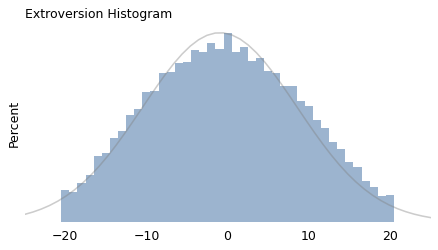

In [ ]:
plot_pmf(big_five["EXT"], **bar_options)

decorate(title="Extroversion Histogram", **pmf_options)

In [ ]:
def plot_cdf(series, **options):
    """Plot a CDF and a Gaussian CDF with the same mean and std.

    series: Series
    options: passed to plt.plot
    """
    cdf_series = make_cdf(series)
    mu, sigma = fit_gaussian(series)
    qs = np.linspace(-25, 25)
    ps = norm.cdf(qs, mu, sigma) * 100
    plt.plot(qs, ps, color="gray", alpha=0.4)
    cdf_series.plot(**options)

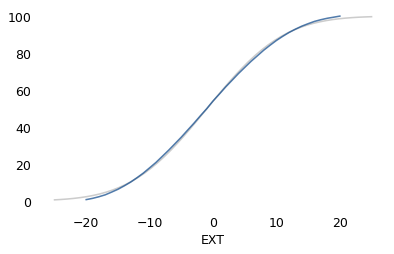

In [ ]:
plot_cdf(big_five["EXT"])

The survey consists of 50 questions, with 10 questions intended to measure each of the five personality traits.
For example, one of the prompts related to extroversion is "I feel comfortable around people;" one of the prompts related to emotional stability is "I am relaxed most of the time."
People respond on a five-point scale from "Strongly Disagree" to "Strongly Agree".
I scored the responses like this:

* "Strongly agree" scores 2 points.

* "Agree" scores 1 point,

* "Neutral" scores 0 points,

* "Disagree" scores -1 point, and

* "Strongly disagree" scores -2 points.

For some questions, the scale is reversed; for example, if someone strongly agrees that they are "quiet around strangers," that counts as -2 points on the extroversion score.

Since there are 10 questions for each trait, the maximum score is 20 and the minimum score is -20.
For each of the five traits, the following figure shows the distributions of total scores for more than 800,000 respondents.

In [ ]:
traits = {
    "EXT": "Extroversion",
    "EST": "Emotional stability",
    "CSN": "Conscientiousness",
    "AGR": "Agreeableness",
    "OPN": "Openness",
}

In [ ]:
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

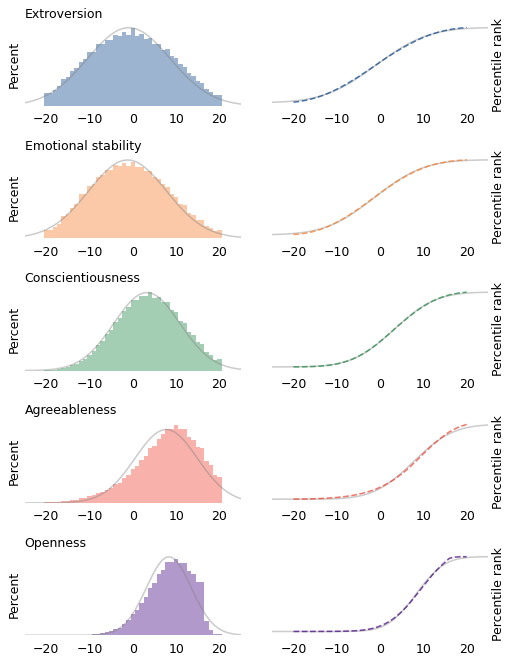

In [ ]:
plt.figure(figsize=(7, 9))
shape = (5, 2)
colspan = 1

for i, trait in enumerate(traits):
    series = big_five[trait]
    plt.subplot2grid(shape, (i, 0), colspan=colspan)
    plot_pmf(series, color=colors[i], **bar_options)
    title = f"{traits[trait]}"
    decorate(title=title, **pmf_options)

    plt.subplot2grid(shape, (i, 1), colspan=colspan)
    plot_cdf(series, ls="--", color=colors[i])
    title = f"{traits[trait]} CDF"
    decorate(legend=False, **cdf_options)
    plt.gca().yaxis.set_label_position("right")

The figures on the left show histograms; the figures on the right show CDFs.
In both figures, the shaded line is a Gaussian distribution I chose to fit the data.
The Gaussian model fits the first three distributions well (extroversion, emotional stability, and conscientiousness) except in the extreme tails.

The other two distributions are skewed to the left; that is, their tails extend farther left than right.
It's possible that these deviations from the Gaussian model are the result of measurement error.
In particular, agreeableness and openness might be subject to social desirability bias, which is the tendency of survey respondents to shade their answers to questions like these in the direction they know is more socially acceptable.

For example, two of the prompts related to agreeableness are
"I am not interested in other people's problems," and
"I insult people."
It's possible that even callous, abrasive people are sensitive enough to avoid admitting these faults.

Similarly, two of the prompts related to openness are
"I use difficult words," and
"I have excellent ideas."
It's possible that some people with a limited vocabulary are mistaken about the quality of their ideas.

On the other hand, it seems like at least some unconscientious people are willing to admit that "I leave my belongings around," and "I shirk my duties."
So it may be that these measurements reflect actual distributions of these attributes in the population, and it just happens that those distributions are not very Gaussian.

Regardless, let's see what happens if we apply Daniels's analysis to the Big Five data.
The following table shows the mean and standard deviation of the five scores, the range of values we'll consider "approximately average", and the percentage of the sample that falls in that range.

In [ ]:
res = []

for trait in traits:
    series = big_five[trait]
    mu, sigma = series.mean(), series.std()
    num_std = 0.3
    low, high = np.array([-num_std, num_std]) * sigma + mu
    # low, high = np.percentile(series, [37, 63])
    nearly_average = series.between(low, high)
    percent = nearly_average.mean() * 100
    res.append((trait, mu, sigma, low, high, percent))

In [ ]:
columns = ["Trait", "Mean", "Std Dev", "Low", "High", "% in range"]
index = list(traits.values())
table = pd.DataFrame(res, columns=columns, index=index)
table.index.name = "Trait"

compress_table(table.drop(columns=["Trait"]).round(1))

Trait,Mean,Std Dev,Low,High,% in range
Extroversion,-0.4,9.1,-3.1,2.3,23.4
Emotional stability,-0.7,8.6,-3.2,1.9,20.9
Conscientiousness,3.7,7.4,1.4,5.9,20.2
Agreeableness,7.7,7.3,5.5,9.9,21.1
Openness,8.5,5.2,7.0,10.1,28.3


In [ ]:
average_table = pd.DataFrame(index=big_five.index, dtype=bool)

for trait_name, row in table.iterrows():
    trait, _, _, low, high, _ = row
    print(low, high)
    average_table[trait] = big_five[trait].between(low, high)

average_table.mean()

-3.1372871601929004 2.3252877053311494
-3.242306090116485 1.9093743572296462
1.448295151003666 5.872767227242111
5.547085266391241 9.923379349440902
6.998641959567459 10.09724854552145


EXT    0.233719
EST    0.209079
CSN    0.201916
AGR    0.210914
OPN    0.283486
dtype: float64

In [ ]:
average_table.head()

,EXT,EST,CSN,AGR,OPN
0,False,False,True,True,False
1,False,False,False,False,True
2,False,False,True,False,False
3,False,True,False,True,True
4,True,False,False,False,False


In [ ]:
array = np.cumprod(average_table.values, axis=1)

cumulative_table = pd.DataFrame(
    array, index=average_table.index, columns=average_table.columns, dtype=bool
)

cumulative_table.head()

,EXT,EST,CSN,AGR,OPN
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,True,False,False,False,False


For each trait, the "average" range contains 20-28% of the population.
Now if we treat each trait as a hurdle and select people who are close to average on each one, the following table shows the results.

In [ ]:
len(big_five)

873173

In [ ]:
counts = cumulative_table.sum()
index = counts.index.to_series().replace(traits)
index.name = 'Trait'

results = pd.DataFrame({"Counts": counts.values}, index=index)
results["Percentages"] = counts.values / len(big_five) * 100

compress_table(results.round(1))

Trait,Counts,Percentages
Extroversion,204077,23.4
Emotional stability,46988,5.4
Conscientiousness,10976,1.3
Agreeableness,2981,0.3
Openness,926,0.1


The first column shows the number of people who make it past each hurdle; the second column shows the percentages.

Of the 873,173 people we started with, about 204,000 are close to the average in extroversion.
Of those, about 47,000 are close to the average in emotional stability.
And so on, until we find 926 who are close to average on all five traits, which is barely one person in a thousand.

As Daniels showed with physical measurements, we have shown with psychological measurements: when we consider more than a few dimensions, people who are close to the average are rare or nonexistent.
In fact, nearly everyone is far from average by some measure.

But that's not all.
If we consider a large number of measurements, it's not just that everyone is far from average; it turns out that everyone is approximately the same distance from average.
We'll see why in the next section.

## We Are All Equally Weird

How weird are you? One way to quantify that is to count the number of measurements where you are far from average.

For example, using the Big Five data again, I counted the number of traits where each respondent falls outside the range we defined as "approximately average".
We can think of the result as a kind of "weirdness score", where 5 means they are far from average on all five traits, and 0 means they are far from average on none.

The following figure shows the distribution of these scores for the roughly 800,000 people who completed the Big Five survey.

In [ ]:
def summarize(varname, series):
    """Summarize the values in a series.

    varname: string
    series: Series

    low and high are the bounds of the "average" range
    n is the number of people who fall in that range

    return: tuple of (varname, mean, std, low, high, n)"""
    mu, sigma = series.mean(), series.std()
    num_std = 0.3
    low, high = np.array([-num_std, num_std]) * sigma + mu
    nearly_average = series.between(low, high)
    n = nearly_average.sum()
    return varname, mu, sigma, low, high, n

In [ ]:
def make_summary_table(df, measurements, columns):
    """Make a table summarizing a set of measurements.

    df: DataFrame
    measurements: list of column names

    returns: DataFrame with the columns from summarize
    """
    res = []

    for varname in measurements:
        series = df[varname]
        t = summarize(varname, series)
        res.append(t)

    return pd.DataFrame(res, columns=columns)

In [ ]:
def make_standardized_table(df, summary_table):
    """Compute standardized measurements.

    Express measurements in terms of standard deviations from the mean.

    df: DataFrame to get the original values from
    summary_table: DataFrame to get the rows from

    returns: DataFrame
    """
    d = {}
    for measurement, row in summary_table.iterrows():
        varname, mean, std, low, high, _ = row
        d[varname] = np.abs(df[varname] - mean) / std
    return pd.DataFrame(d)

In [ ]:
def make_weird_table(df, summary_table):
    """Make a table counting number of weirdness points.

    df: DataFrame to get the data from
    summary_table: DataFrame to get the rows from

    returns: DataFrame
    """
    d = {}
    for measurement, row in summary_table.iterrows():
        varname, mean, std, low, high, _ = row
        is_average = df[varname].between(low, high)
        d[varname] = np.where(is_average, 0, 1)
    return pd.DataFrame(d)

In [ ]:
columns = ["Trait", "Mean", "Std Dev", "Low", "High", "# in range"]
summary_table = make_summary_table(big_five, traits, columns)
summary_table

,Trait,Mean,Std Dev,Low,High,# in range
0,EXT,-0.406000,9.104291,-3.137287,2.325288,204077
1,EST,-0.666466,8.586134,-3.242306,1.909374,182562
2,CSN,3.660531,7.374120,1.448295,5.872767,176308
3,AGR,7.735232,7.293823,5.547085,9.923379,184164
4,OPN,8.547945,5.164344,6.998642,10.097249,247532


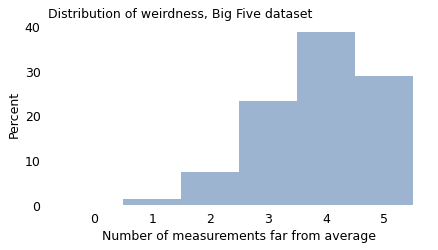

In [ ]:
std_table = make_weird_table(big_five, summary_table)
weirdness = std_table.sum(axis=1)

pmf = Pmf.from_seq(weirdness)
pmf *= 100
pmf.bar(**bar_options)

decorate(
    xlabel="Number of measurements far from average",
    ylabel="Percent",
    title="Distribution of weirdness, Big Five dataset",
)

In [ ]:
pmf[4:6].sum()

67.6952906239657

As we've already seen, very few people are close to average on all five traits.
Almost everyone is weird in two or more ways, and the majority (68\%) are weird in four or five ways!

In [ ]:
summary_table = make_summary_table(ansur_male, measurements, columns)
summary_table

,Trait,Mean,Std Dev,Low,High,# in range
0,abdominalextensiondepthsitting,254.650906,37.327178,243.452753,265.849060,886
1,acromialheight,1440.736894,63.287242,1421.750721,1459.723066,974
2,acromionradialelength,335.244488,17.482795,329.999649,340.489327,1054
3,anklecircumference,229.343949,14.649102,224.949218,233.738680,1039
4,axillaheight,1329.082068,59.516123,1311.227231,1346.936905,964
...,...,...,...,...,...,...
88,waistfrontlengthsitting,387.642822,29.349007,378.838120,396.447524,964
89,waistheightomphalion,1056.485301,52.154671,1040.838900,1072.131703,961
90,weightkg,855.239588,142.206992,812.577491,897.901686,983
91,wristcircumference,175.916707,8.955055,173.230191,178.603224,941


In [ ]:
weird_table = make_weird_table(ansur_male, summary_table)
weird_table.mean()

abdominalextensiondepthsitting    0.782950
acromialheight                    0.761391
acromionradialelength             0.741793
anklecircumference                0.745468
axillaheight                      0.763841
                                    ...   
waistfrontlengthsitting           0.763841
waistheightomphalion              0.764576
weightkg                          0.759187
wristcircumference                0.769476
wristheight                       0.758697
Length: 93, dtype: float64

In [ ]:
weird_table.head()

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,...,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight
0,1,1,0,1,1,0,0,1,1,0,...,1,1,0,0,0,1,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
2,1,0,1,0,0,1,1,1,1,1,...,0,0,0,0,1,1,0,1,1,1
3,1,1,1,0,1,1,0,1,0,1,...,1,1,1,1,1,1,1,1,0,1
4,0,1,1,1,1,1,1,1,0,1,...,0,1,1,1,1,0,1,1,1,1


The distribution of weirdness is similar with physical traits.
Using the 93 measurements in the ANSUR dataset, we can count the number of ways each participant deviates from average.
The following figure shows the distribution of these counts for the male ANSUR participants.


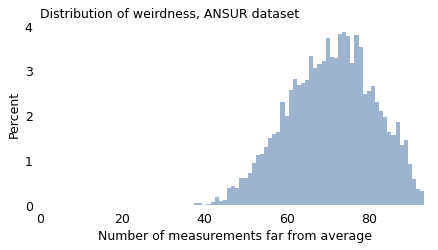

In [ ]:
weirdness = weird_table.sum(axis=1)
pmf = Pmf.from_seq(weirdness)
pmf *= 100
pmf.bar(**bar_options)

decorate(
    xlabel="Number of measurements far from average",
    xlim=[0, 95],
    ylabel="Percent",
    title="Distribution of weirdness, ANSUR dataset",
)

Nearly everyone in this dataset is "weird" in at least 40 ways, and 90\% of them are weird in at least 57 ways.
With enough measurements, being weird is normal.

In fact, as the number of measurements increases, the width of this distribution gets narrower; that is, the difference between the most normal person and the weirdest gets smaller.

To demonstrate, I'll use the ANSUR measurements to compute all possible ratios of two measurements.
Some of these ratios are more meaningful than others, but at least some of them are features that affect clothing design (like the ratio of waist circumference to chest circumference),
cockpit design (like the ratio of arm length to leg length), or perceived attractiveness (like the ratio of face width to face height).

With 93 measurements and 4278 ratios, there are a total of 4317 ways to be weird.
The following figure shows the distribution of weirdness scores for the male participants.

In [ ]:
weirdness.mean()

70.78637922586967

In [ ]:
np.percentile(weirdness, [10])

array([57.])

In [ ]:
d = {}
for i, varname1 in enumerate(measurements):
    for j, varname2 in enumerate(measurements):
        if i <= j:
            continue
        colname = varname1 + varname2
        d[colname] = ansur_male[varname1] / ansur_male[varname2]

ratio_frame = pd.DataFrame(d)
ratio_frame.head()

,acromialheightabdominalextensiondepthsitting,acromionradialelengthabdominalextensiondepthsitting,acromionradialelengthacromialheight,anklecircumferenceabdominalextensiondepthsitting,anklecircumferenceacromialheight,anklecircumferenceacromionradialelength,axillaheightabdominalextensiondepthsitting,axillaheightacromialheight,axillaheightacromionradialelength,axillaheightanklecircumference,...,wristheighttrochanterionheight,wristheightverticaltrunkcircumferenceusa,wristheightwaistbacklength,wristheightwaistbreadth,wristheightwaistcircumference,wristheightwaistdepth,wristheightwaistfrontlengthsitting,wristheightwaistheightomphalion,wristheightweightkg,wristheightwristcircumference
0,5.515038,1.266917,0.229721,0.834586,0.151329,0.658754,5.063910,0.918200,3.997033,6.067568,...,0.928183,0.501765,1.702595,2.592705,0.914255,3.554167,1.938636,0.809298,1.046626,4.874286
1,5.987124,1.399142,0.233692,0.944206,0.157706,0.674847,5.549356,0.926882,3.966258,5.877273,...,0.887800,0.500922,1.886574,2.579114,0.936782,3.622222,2.196765,0.773245,1.122590,4.880240
2,4.982578,1.188153,0.238462,0.801394,0.160839,0.674487,4.623693,0.927972,3.891496,5.769565,...,0.905229,0.495232,1.760593,2.525836,0.862033,3.258824,2.021898,0.798271,0.894510,4.616667
3,5.756410,1.324786,0.230141,0.982906,0.170750,0.741935,5.294872,0.919822,3.996774,5.386957,...,0.936246,0.488000,1.720174,2.517460,0.925321,3.868293,1.987469,0.819215,0.998741,4.505682
4,6.340000,1.488000,0.234700,0.988000,0.155836,0.663978,5.912000,0.932492,3.973118,5.983806,...,0.875229,0.568195,2.042827,3.148515,1.099078,4.457944,2.517150,0.766265,1.008457,5.074468


In [ ]:
ratio_frame.shape

(4082, 4278)

In [ ]:
ratio_frame = pd.concat([ansur_male[measurements], ratio_frame], axis=1)
ratio_frame.shape

(4082, 4371)

In [ ]:
summary_table2 = make_summary_table(ratio_frame, ratio_frame.columns, columns)
summary_table2.head()

,Trait,Mean,Std Dev,Low,High,# in range
0,abdominalextensiondepthsitting,254.650906,37.327178,243.452753,265.849060,886
1,acromialheight,1440.736894,63.287242,1421.750721,1459.723066,974
2,acromionradialelength,335.244488,17.482795,329.999649,340.489327,1054
3,anklecircumference,229.343949,14.649102,224.949218,233.738680,1039
4,axillaheight,1329.082068,59.516123,1311.227231,1346.936905,964


In [ ]:
weird_table2 = make_weird_table(ratio_frame, summary_table2)
weird_table2.mean()

abdominalextensiondepthsitting        0.782950
acromialheight                        0.761391
acromionradialelength                 0.741793
anklecircumference                    0.745468
axillaheight                          0.763841
                                        ...   
wristheightwaistdepth                 0.773885
wristheightwaistfrontlengthsitting    0.762616
wristheightwaistheightomphalion       0.759187
wristheightweightkg                   0.760412
wristheightwristcircumference         0.760412
Length: 4371, dtype: float64

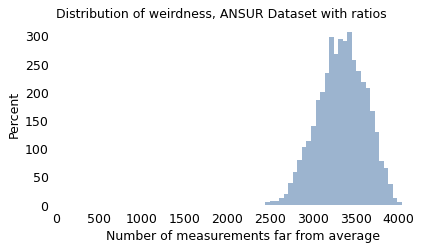

In [ ]:
weirdness2 = weird_table2.sum(axis=1)
plt.hist(weirdness2, bins=30, fill=True, alpha=0.4)

decorate(
    xlabel="Number of measurements far from average",
    xlim=[0, 4371],
    ylabel="Percent",
    title="Distribution of weirdness, ANSUR Dataset with ratios",
)

With these measurements, all participants fall in a relatively narrow range of weirdness.
The most "normal" participant deviates from average in 2446 ways; the weirdest in 4038 ways.

Now, you might notice that the distribution of this weirdness score has the characteristic shape of a Gaussian curve, and that is not a coincidence.
Mathematically, as the number of measurements increases, the distribution of weirdness converges to a Gaussian distribution and the width of the distribution gets narrower.
In the limit, if we consider the nearly infinite ways people vary, we find that we are all equally weird.

In [ ]:
weirdness2.quantile([0, 0.05, 0.5, 0.95, 1])

0.00    2446.00
0.05    2853.05
0.50    3343.00
0.95    3768.95
1.00    4038.00
dtype: float64

## But Some Are More Equal Than Others

In some ways, this chapter is a feel good story.
If at times in your life you have felt different, you are not alone; everyone is different in many ways.
And if you think you're normal and other people aren't, you are wrong on both counts.

But the real world is not like the mathematical world, and I want to be careful not to push this point too far.
The idea that we are all equally weird is only true if the different ways of being different are treated the same.
And that's not the case.

Considering the measurements in this chapter, some are more visible than others.
If your menton-sellion length is in the 90th percentile, people will notice your long face, and if you are a famous actress, Seth MacFarlane will make fun of it.
But if your lateral malleolus height is in the 90th percentile, you were probably not teased as a child because your ankle bone is unusually far from the ground.

Among personality traits, some kinds of variation are met more favorably than others.
For the most part, we accept introversion and extroversion as equally valid ways to be, but some of the other traits are more laden with value judgments.
In general, we consider it better to be conscientious than unreliable, and better to be agreeable than obnoxious.

Also, the world is designed to handle some kinds of variation better than others.
For example, while introversion might not be considered a moral failing, many introverts find that school and work environments reward extroversion more than might be merited.

The world handles some kinds of physical variation better than others, too.
In *Invisible Women*, Caroline Criado Perez writes about many ways our built environment, designed primarily with men in mind, does not always fit women.
Safety features in cars, tested on crash dummies with male proportions, protect women less effectively.
Many smartphones are difficult to use one-handed if your hands are smaller than average.
And, as more than half of the population discovered during the COVID-19 pandemic, a lot of personal protective equipment (PPE) is "based on the sizes and characteristics of male populations from certain countries in Europe and the United States. As a result, most women, and also many men, experience problems finding suitable and comfortable PPE," according to the Trades Union Congress in the United Kingdom.

Furthermore, the way I defined a "weirdness score" is too blunt.
To be consistent with Daniels's analysis, I consider only two categories: approximately average or not.
In reality, our ability to handle variation has many levels.
If you are a little taller or shorter than average, you have to adjust your car seat, but you might not even notice the inconvenience.
But if you are too short to stand behind a "standard" lectern, or too tall to walk through a door without ducking, you will notice that the world is not designed for you.
And at greater extremes, when the mismatch between you and the world makes common tasks difficult or impossible, we call it a disability -- and implicitly put the blame on the person, not the built environment.

So, when I say we are all equally weird, my intent is to point out the ways variability defies our intuitive concepts of "normal" and "weird".
I don't mean to say that the world treats us as equally weird; it doesn't.

## Sources and related reading

* The ANSUR-II dataset is available from the [Open Design Lab at Penn State](https://www.openlab.psu.edu/ansur2/), published by the U.S. Army Natick Soldier Research, Development and Engineering Center in 2012. The measurements are described in the [*Measurer's Handbook: US Army and Marine Corps Anthropometric Surveys, 2010-2011*](http://tools.openlab.psu.edu/publicData/ANSURII-TR11-017.pdf) by Jennifer Hotzman and colleagues (2011), which is more interesting than you might expect, especially if you need to know the proper term of address for a Marine Master Gunnery Sergeant.

* My example from a pediatric growth chart is from the Centers for Disease Control and Prevention (CDC) [growth charts](https://www.cdc.gov/growthcharts/data/set1clinical/cj41c017.pdf) published in 2022.

* You can take a version of the Big Five Personality Test, called the International Personality Item Pool (IPIP), [online](https://openpsychometrics.org/tests/IPIP-BFFM) from the Open-Source Psychometrics Project (2019).

* Gilbert S. Daniels's 1952 paper "The 'Average Man'?" is available from the [Defense Technical Information Center](https://apps.dtic.mil/sti/pdfs/AD0010203.pdf) (Technical Report RDO No. 695-71, Air Force Aerospace Medical Research Lab, Wright-Patterson AFB, Ohio).

* Todd Rose wrote about the myth of the average person in *The end of average: How to succeed in a world that values sameness* (Penguin UK, 2016).

* Caroline Criado Perez described some of the ways the world is ill-designed for women in a [2019 article in *The Guardian*](https://www.theguardian.com/lifeandstyle/2019/feb/23/truth-world-built-for-men-car-crashes), which was based on her book *Invisible Women: Data bias in a world designed for men* (Abrams, 2019).

* The [report on PPE and women](https://www.tuc.org.uk/research-analysis/reports/personal-protective-equipment-and-women) was published by the Trades Union Congress (TUC) in 2017.

* Sara Hendren wrote about the ways the world is ill-designed for people who are far from average in *What Can a Body Do?: How We Meet the Built World* (Penguin, 2020).

Probably Overthinking It

Copyright 2022 Allen Downey

